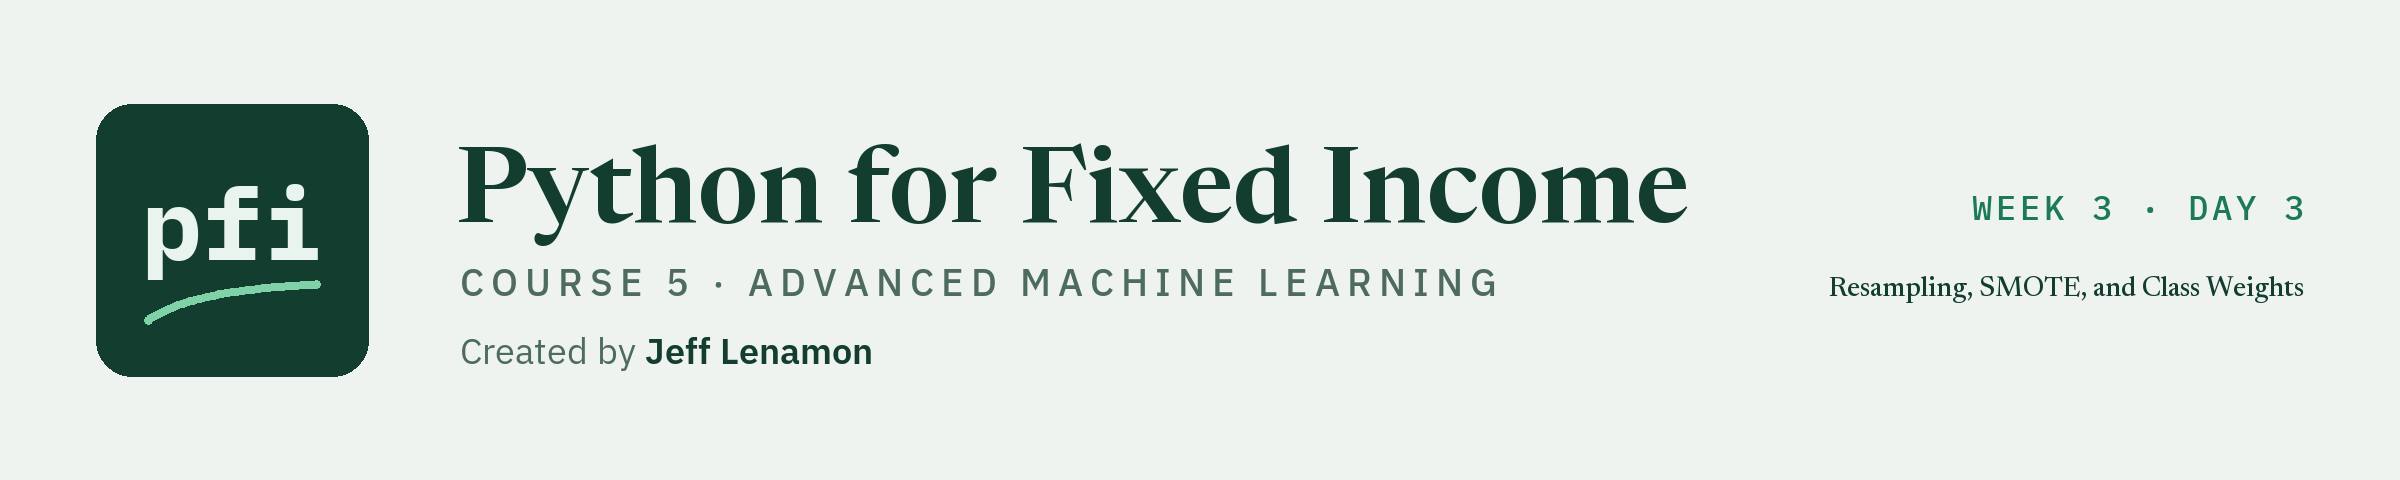

# Resampling, SMOTE, and Class Weights

Week 3, Day 3. When one outcome is rare, a model can be told to make it count: class weights, oversampling, undersampling, or SMOTE. Today: what each one does to the rows, why resampling belongs inside the pipeline, what it does to ranking and to the output's average, and how to correct a score that resampling moved.

**Data:** `polish_bankruptcy_5year.csv`, 5,910 financial statements of Polish companies: **real**, UCI Machine Learning Repository dataset 365, CC BY 4.0. Citation: Tomczak, S. (2016). Polish Companies Bankruptcy [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5F600.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course5_advanced_ml/week3/day3/13_resampling_smote_and_class_weights.ipynb)

On the Polish training rows, 326 companies of 4,680 went bankrupt: 6.97 percent. A model fitted to rows like these sees about thirteen healthy companies for every bankrupt one. The usual advice, in tutorials and in AI answers, is to "fix the imbalance" before fitting: weight the rare rows, copy them, drop common rows, or make up new rare rows with SMOTE. Today tests that advice on this file, with numbers, and looks at what each fix does to the model's output as a number, not only as a ranking.

**The Polish rules, as on every week 3 day.**

* **The data is real.** `polish_bankruptcy_5year.csv` is the UCI file Course 4's capstone modelled: annual statements of Polish companies from 2000 to 2013, 64 financial ratios each (`Attr1` to `Attr64`, read as the page's X1 to X64), and a flag for bankruptcy. One country's companies; the accounting rules and bankruptcy law differ from US corporate credit.
* **Course 4's test rows stay closed.** Course 4's capstone opened its 1,170 Polish test rows once; by the test-row rule (day 1), Course 5 never scores them, and `ensemblekit.course4_polish_rows` never returns them. Every number today comes from cross-validation inside the 4,680 training rows.
* **A model's output is described, never acted on.** An unweighted model's output is the model probability of bankruptcy in this file, or a flag at a threshold. A model fitted with class weights or on resampled rows gives **the model's score**: its average is not the bankrupt share, as section 13.6 measures, so it is not called a probability until it is recalibrated (section 13.8). No output is a credit view on any company.

Today you will:

1. Fit LightGBM to the rare outcome as it is, and read its output's average.
2. Make the rare class count four ways, and count the rows each one leaves with `class_counts_after`.
3. Find SMOTE's first made-up company on the line between two real ones.
4. Put resampling inside an `imblearn` pipeline, and see the score SMOTE before cross-validation reports.
5. Rank eight models by out-of-fold average precision.
6. Compare each output's average with the bankrupt share.
7. Reach the same recall with a threshold instead of resampling.
8. Recalibrate a resampled score with `prior_correction` and with isotonic calibration.

Q. Set up today's work folder: the thread settings, the seed, the modules as day 12 left them, and the data files.

In [1]:
# today's setup: the thread settings, the modules, the seed, the course data, and a fresh work folder
import os

# one thread for the maths libraries, so every run of the notebook gives the same last digits.
# These two lines must run before numpy, pandas, scikit-learn, XGBoost, or LightGBM is imported: if you ran another
# cell first, restart the kernel and run this cell first (in Colab: Runtime, Restart session).
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

import importlib
import importlib.metadata
import importlib.util
import platform
import shutil
import subprocess
import sys
import tempfile
import urllib.request
from pathlib import Path

# packages a Colab runtime or a new environment may lack: stop with the line that installs the missing one
for module_name, install_name in [("sklearn", "scikit-learn"), ("statsmodels", "statsmodels"), ("scipy", "scipy"), ("xgboost", "xgboost"), ("lightgbm", "lightgbm"), ("imblearn", "imbalanced-learn"), ("shap", "shap"), ("pytest", "pytest")]:
    if importlib.util.find_spec(module_name) is None:
        raise RuntimeError(f"{install_name} is not installed. Run  !pip install {install_name}  in a new cell, "
                           "then run this cell again.")

import numpy as np
import pandas as pd

# the versions the saved outputs of this notebook came from (course5_advanced_ml/requirements.txt)
PINNED = {"numpy": "2.5.3", "pandas": "3.0.6", "scikit-learn": "1.9.1", "scipy": "1.18.1", "xgboost": "3.4.1", "lightgbm": "4.7.0", "imbalanced-learn": "0.14.2", "shap": "0.52.0", "matplotlib": "3.11.2", "pytest": "9.1.1"}
installed = {name: importlib.metadata.version(name) for name in PINNED}
print(f"Python {platform.python_version()}; " + ", ".join(f"{name} {version}" for name, version in installed.items()))
different = [name for name in PINNED if installed[name] != PINNED[name]]
if different:
    print(f"Not the course's pinned version: {', '.join(different)}. Printed numbers may differ in the last digits from the saved notebook.")

# the seed: one number for every random choice the course makes, so every run makes the same choices
SEED = 42

# remember the notebook's own folder, so that running this cell again starts from the same place
if "notebook_folder" not in globals():
    notebook_folder = Path.cwd()

# 1. find the course data before moving: the repo's data folder on your machine, GitHub in Colab
RAW_DATA = "https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/"
local_data = (notebook_folder / ".." / ".." / ".." / "data").resolve()
on_github = not (local_data / "credit_card_default.csv").exists()

# 2. a fresh work folder for today, in the system temp folder, outside the course repo
work = Path(tempfile.mkdtemp(prefix="pfi_course5_13_"))
os.chdir(work)

# 3. copy today's data files into the work folder
DATA_FILES = ["credit_card_default.csv", "benchmark.csv", "ratings.csv", "polish_bankruptcy_5year.csv"]
for name in DATA_FILES:
    if on_github:
        urllib.request.urlretrieve(RAW_DATA + name, work / name)
    else:
        shutil.copy(local_data / name, work / name)

# print the folder's name only: its full path would show your user name
print(f"Work folder: {work.name}, in your temp folder")
print(f"Data files from {'GitHub' if on_github else 'the data folder of the course repo'}: {', '.join(DATA_FILES)}")
print(f"SEED = {SEED}")

Python 3.13.8; numpy 2.5.3, pandas 3.0.6, scikit-learn 1.9.1, scipy 1.18.1, xgboost 3.4.1, lightgbm 4.7.0, imbalanced-learn 0.14.2, shap 0.52.0, matplotlib 3.11.2, pytest 9.1.1
Work folder: pfi_course5_13_9k8kmy4c, in your temp folder
Data files from the data folder of the course repo: credit_card_default.csv, benchmark.csv, ratings.csv, polish_bankruptcy_5year.csv
SEED = 42


Q. Write `mlkit.py`, Course 4's complete module, unchanged. `ensemblekit` imports it.

In [2]:
%%writefile mlkit.py
"""mlkit: the small pieces of machine learning that scikit-learn leaves to the analyst, written down and tested.

Written day by day in Python for Fixed Income, Course 4: Machine Learning.

Conventions, the same in every function:
- The seed is 42 wherever a function takes one, so every run gives the same numbers.
- Spreads are in basis points (bp). A model of log_oas is fitted in natural logs of bp; its errors are reported
  in bp after exp, and exp of a fitted log is a median-type value, not a mean.
- The positive class is 1 (default, bankrupt). Precision, recall, and F1 are for class 1 only.
- A row is flagged when its model probability is at least the threshold (probability >= threshold).
- Rows that fit a model, rows that choose a setting, and rows that report a result are kept apart; the split
  functions here prove it with a check that stops.
- Inputs of the wrong shape, or empty inputs, raise ValueError with a message that says what was wrong.
"""
import numpy as np  # arrays and arithmetic
import pandas as pd  # tables with labels
from numpy.typing import ArrayLike  # a list, an array, or a pandas Series


def assert_disjoint(train_index: ArrayLike, test_index: ArrayLike) -> None:
    """Stop if any row label is in both the training rows and the test rows.

    Inputs: the labels (or positions) of the rows in each part, for example X_train.index and X_test.index.
    Output: None when the parts share no label.
    Convention: a row in both parts is a test row the model has already seen, which flatters every metric.
    Raises AssertionError naming how many labels are in both parts, and ValueError if either part is empty.
    """
    # the labels of each part as sets
    train = set(np.asarray(train_index).tolist())
    test = set(np.asarray(test_index).tolist())
    if not train or not test:
        raise ValueError("train_index and test_index must both hold at least one label")
    # the labels found in both parts
    shared = train & test
    if shared:
        raise AssertionError(f"{len(shared)} row labels are in both the training and the test rows")


def _as_1d_array(values: ArrayLike, name: str) -> np.ndarray:
    """Return `values` as a 1-D float array, or raise ValueError naming the input."""
    array = np.asarray(values, dtype=float)
    if array.ndim != 1:
        raise ValueError(f"{name} must be one-dimensional, not {array.ndim}-dimensional")
    if array.size == 0:
        raise ValueError(f"{name} is empty")
    return array


def regression_metrics(y_true: ArrayLike, y_fitted: ArrayLike) -> dict[str, float]:
    """R-squared, mean absolute error, and root mean squared error of fitted values.

    Inputs: y_true and y_fitted, the same length, in the target's unit (for example oas in bp).
    Output: {"r2", "mae", "rmse"}. r2 is unitless, 1 - SS_res / SS_tot on the rows given (on test rows it can
    be negative); mae and rmse are in the target's unit. For a log_oas model, pass exp of both to get bp.
    Convention: equal to scikit-learn's r2_score, mean_absolute_error, and root_mean_squared_error.
    Excel: =RSQ(...) only for a straight line on one feature; =AVERAGE(ABS(a-b)) and =SQRT(SUMXMY2(a,b)/COUNT(a)).
    Raises ValueError if the inputs are empty, not one-dimensional, or of different lengths.
    """
    # check both inputs and that they line up row for row
    actual = _as_1d_array(y_true, "y_true")
    fitted = _as_1d_array(y_fitted, "y_fitted")
    if actual.size != fitted.size:
        raise ValueError(f"y_true has {actual.size} values and y_fitted has {fitted.size}")
    # each error in the target's unit
    errors = actual - fitted
    # R-squared: the share of the spread around the mean that the fitted values account for
    ss_res = float(np.sum(errors ** 2))
    ss_tot = float(np.sum((actual - actual.mean()) ** 2))
    r2 = 1 - ss_res / ss_tot
    # the average size of an error, and the square root of the average squared error
    mae = float(np.mean(np.abs(errors)))
    rmse = float(np.sqrt(np.mean(errors ** 2)))
    return {"r2": r2, "mae": mae, "rmse": rmse}


def adjusted_r2(r2: float, n_rows: int, n_features: int) -> float:
    """Adjusted R-squared: R-squared with a charge for each feature.

    Inputs: r2 on the training rows (unitless), n_rows the number of training rows, n_features the number of
    features not counting the intercept.
    Output: 1 - (1 - r2) x (n_rows - 1) / (n_rows - n_features - 1), unitless. An in-sample measure, so it is
    computed on training rows only.
    Excel: =1-(1-R2)*(n-1)/(n-k-1)
    Raises ValueError if n_features is negative or n_rows is not above n_features + 1.
    """
    # the formula needs at least one degree of freedom left after the features and the intercept
    if n_features < 0:
        raise ValueError(f"n_features must be 0 or more, not {n_features}")
    if n_rows <= n_features + 1:
        raise ValueError(f"n_rows ({n_rows}) must be greater than n_features + 1 ({n_features + 1})")
    # scale the unexplained share by the ratio of degrees of freedom
    return 1 - (1 - r2) * (n_rows - 1) / (n_rows - n_features - 1)


def rating_dummies(ratings: pd.Series, levels: list[str], reference: str) -> pd.DataFrame:
    """One indicator column per rating level except the reference level, which the intercept stands for.

    Inputs: ratings, one text rating per bond (for example "BBB+"); levels, every allowed level in the order the
    columns should follow (the rating column of ratings.csv, known in advance, not learned from the data);
    reference, the level left out.
    Output: a DataFrame with the same index, one float column (0.0 or 1.0) per level except reference, named
    rating_<level>, in the order of levels. A coefficient on rating_BB is then the difference from a bond rated
    `reference`, other features fixed.
    Convention: floats, not booleans, so every library and an Excel formula read the same 0.0 and 1.0. The
    reference is named by the caller, never chosen by alphabetical order.
    Raises ValueError if ratings is empty, reference is not in levels, or a rating is not in levels.
    """
    # check the inputs before building anything
    if len(ratings) == 0:
        raise ValueError("ratings is empty")
    if reference not in levels:
        raise ValueError(f"reference {reference!r} is not one of the levels")
    unknown = sorted(set(ratings) - set(levels))
    if unknown:
        raise ValueError(f"ratings not in levels: {unknown}")
    # one column per level, 1.0 where the bond has that rating
    columns = {f"rating_{level}": (ratings == level).astype(float) for level in levels if level != reference}
    return pd.DataFrame(columns, index=ratings.index)


def vif_table(X: pd.DataFrame) -> pd.Series:
    """Variance inflation factor of each feature: how much its coefficient's variance grows from the overlap with
    the other features.

    Input: X, the features as numeric columns (no constant column; one is added inside).
    Output: a Series named vif, one value per column, sorted from highest to lowest. VIF_j = 1 / (1 - R2_j),
    where R2_j is the R-squared of column j regressed on a constant and every other column. 1 means no overlap;
    above 5 is called high and above 10 very high, as conventions. A column that is an exact copy (or exact
    combination) of others has R2_j = 1 and VIF infinity.
    Convention: equal to statsmodels' variance_inflation_factor on X with a constant added.
    Excel: =1/(1-INDEX(LINEST(xj, other columns, TRUE, TRUE), 3, 1))
    Raises ValueError if X has fewer than two columns or fewer rows than columns plus two.
    """
    # check there is something to regress on, and enough rows to do it
    if X.shape[1] < 2:
        raise ValueError(f"X needs at least two columns, not {X.shape[1]}")
    if X.shape[0] < X.shape[1] + 2:
        raise ValueError(f"X has {X.shape[0]} rows, too few for {X.shape[1]} columns")
    values = X.to_numpy(dtype=float)
    result = {}
    for j, name in enumerate(X.columns):
        # column j is the target; a constant and the other columns are the features
        target = values[:, j]
        others = np.column_stack([np.ones(len(values)), np.delete(values, j, axis=1)])
        # least squares fit and its R-squared
        coefficients, *_ = np.linalg.lstsq(others, target, rcond=None)
        ss_res = float(np.sum((target - others @ coefficients) ** 2))
        ss_tot = float(np.sum((target - target.mean()) ** 2))
        r2 = 1 - ss_res / ss_tot
        # an exact combination of the others leaves no residual (R-squared 1 to the last digit): the VIF is infinite
        result[name] = np.inf if r2 >= 1 else 1 / (1 - r2)
    return pd.Series(result, name="vif").sort_values(ascending=False)


from scipy import stats  # Jarque-Bera and Shapiro-Wilk
from statsmodels.stats.diagnostic import het_breuschpagan  # Breusch-Pagan
from statsmodels.tools import add_constant  # the intercept column


def residual_tests(residuals: pd.Series, exog: pd.DataFrame) -> dict[str, float]:
    """p-values of three checks on a regression's residuals: constant variance and normality (two tests).

    Inputs: residuals, actual minus fitted on the training rows, in the target's unit; exog, the features the
    model was fitted on, without a constant (one is added inside), with the same rows.
    Output: {"breusch_pagan", "jarque_bera", "shapiro_wilk"}, each a p-value between 0 and 1. A small p-value
    (below 0.05, the course's convention) means the data would be surprising if the assumption held:
    - breusch_pagan: statsmodels het_breuschpagan with its default (Koenker's form, n x R-squared of the squared
      residuals regressed on a constant and exog); the assumption is constant variance;
    - jarque_bera: scipy.stats.jarque_bera (skew and kurtosis); the assumption is normal residuals;
    - shapiro_wilk: scipy.stats.shapiro; the assumption is normal residuals.
    Excel has no function for these; Breusch-Pagan can be built from LINEST and CHISQ.DIST.RT.
    Raises ValueError if the inputs are empty or have different numbers of rows.
    """
    # check the two inputs line up
    if len(residuals) == 0 or len(exog) == 0:
        raise ValueError("residuals and exog must not be empty")
    if len(residuals) != len(exog):
        raise ValueError(f"residuals has {len(residuals)} rows and exog has {len(exog)}")
    values = np.asarray(residuals, dtype=float)
    # Breusch-Pagan: returns the LM statistic, its p-value, then an F form; the LM p-value is kept
    _, bp_pvalue, _, _ = het_breuschpagan(values, add_constant(np.asarray(exog, dtype=float), has_constant="add"))
    # the two normality tests
    jb_pvalue = stats.jarque_bera(values).pvalue
    sw_pvalue = stats.shapiro(values).pvalue
    return {"breusch_pagan": float(bp_pvalue), "jarque_bera": float(jb_pvalue), "shapiro_wilk": float(sw_pvalue)}


from sklearn.pipeline import Pipeline  # the type of a chain of steps


def named_coefficients(pipeline: Pipeline) -> pd.Series:
    """The fitted coefficients of a pipeline's last step, labelled with the feature names that step saw.

    Input: a fitted scikit-learn Pipeline whose last step has coef_ (LinearRegression, Ridge, Lasso,
    LogisticRegression) and whose step before it has get_feature_names_out (a ColumnTransformer, a scaler).
    Output: a Series of coefficients indexed by feature name, in the order the model used them. Units: per unit
    of each feature as the model saw it, so per standard deviation after StandardScaler; the intercept is not
    included. For a binary LogisticRegression the one row of coef_ is used (log-odds of class 1).
    Raises ValueError if the last step has no coef_ (a tree, for example) or the pipeline has one step only.
    """
    # the model is the last step; the names come from everything before it
    if len(pipeline.steps) < 2:
        raise ValueError("the pipeline needs a preprocessing step before the model")
    model = pipeline.steps[-1][1]
    if not hasattr(model, "coef_"):
        raise ValueError(f"the last step, {type(model).__name__}, has no coef_")
    names = pipeline[:-1].get_feature_names_out()
    # a binary classifier keeps its coefficients in one row; flatten it
    coefficients = np.ravel(model.coef_)
    if coefficients.size != len(names):
        raise ValueError(f"{coefficients.size} coefficients but {len(names)} feature names")
    return pd.Series(coefficients, index=names, name="coefficient")


def odds_ratios(coefficients: pd.Series) -> pd.Series:
    """Odds ratios from logistic regression coefficients: exp of each coefficient, the intercept left out.

    Input: coefficients in log-odds, indexed by feature name, as statsmodels' Logit params (the intercept is
    named "const") or a Series with an entry named "intercept".
    Output: a Series of exp(coefficient) per feature: the factor by which the odds of class 1 multiply for one
    more unit of that feature, other features fixed. The unit is the feature's own (per 10,000 NT dollars if the
    feature was divided by 10,000; per standard deviation if it was scaled).
    Excel: =EXP(coef)
    Raises ValueError if no coefficient is left once the intercept is removed.
    """
    # leave out the intercept: exp of it is the odds when every feature is 0, not a ratio
    slopes = coefficients.drop(labels=["const", "intercept"], errors="ignore")
    if slopes.empty:
        raise ValueError("no coefficients left after removing the intercept")
    return np.exp(slopes).rename("odds_ratio")


def logistic_probability(z: float | ArrayLike) -> float | np.ndarray:
    """The logistic curve: turns log-odds z into a probability between 0 and 1.

    Input: z, a number or an array of numbers in log-odds (intercept plus coefficients times features).
    Output: 1 / (1 + exp(-z)), a float for a number, an array for an array. z = 0 gives 0.5.
    Excel: =1/(1+EXP(-z))
    """
    # numpy's exp works on a number and on an array alike
    probability = 1 / (1 + np.exp(-np.asarray(z, dtype=float)))
    return float(probability) if probability.ndim == 0 else probability


def _check_labels(y_true: ArrayLike, y_flag: ArrayLike) -> tuple[np.ndarray, np.ndarray]:
    """Return both inputs as integer arrays of 0 and 1, or raise ValueError."""
    actual = np.asarray(y_true)
    flagged = np.asarray(y_flag)
    if actual.ndim != 1 or flagged.ndim != 1 or actual.size == 0:
        raise ValueError("y_true and y_flag must be non-empty and one-dimensional")
    if actual.size != flagged.size:
        raise ValueError(f"y_true has {actual.size} values and y_flag has {flagged.size}")
    for name, values in (("y_true", actual), ("y_flag", flagged)):
        others = sorted(set(values.tolist()) - {0, 1})
        if others:
            raise ValueError(f"{name} holds labels other than 0 and 1: {others[:5]}")
    return actual.astype(int), flagged.astype(int)


def confusion_counts(y_true: ArrayLike, y_flag: ArrayLike) -> dict[str, int]:
    """The four cells of the confusion matrix, with 1 (default) as the positive class.

    Inputs: y_true, the actual outcome per row (0 or 1); y_flag, the model's flag per row (0 or 1), for example
    (probability >= threshold).
    Output: {"tn", "fp", "fn", "tp"} as whole numbers: true negatives (0 flagged 0), false positives (0 flagged
    1), false negatives (1 flagged 0), true positives (1 flagged 1). They add up to the number of rows.
    Convention: the same counts as confusion_matrix(y_true, y_flag).ravel() in scikit-learn.
    Excel: =COUNTIFS(actual,1,flag,1) and the other three combinations.
    Raises ValueError on labels other than 0 and 1, empty inputs, or inputs of different lengths.
    """
    actual, flagged = _check_labels(y_true, y_flag)
    # count each combination of actual and flag
    return {"tn": int(np.sum((actual == 0) & (flagged == 0))), "fp": int(np.sum((actual == 0) & (flagged == 1))),
            "fn": int(np.sum((actual == 1) & (flagged == 0))), "tp": int(np.sum((actual == 1) & (flagged == 1)))}


def classification_metrics(y_true: ArrayLike, y_flag: ArrayLike) -> dict[str, float]:
    """Accuracy, precision, recall, and F1 for class 1 (default), from 0/1 flags.

    Inputs: y_true and y_flag, as confusion_counts.
    Output: {"accuracy", "precision", "recall", "f1"}, each between 0 and 1:
    accuracy (TP + TN) / n; precision TP / (TP + FP), the share of flagged rows that are defaults; recall
    TP / (TP + FN), the share of defaults that are flagged; F1 their harmonic mean, 2TP / (2TP + FP + FN).
    Convention: pos_label=1, binary averaging, zero_division=0 (a model that flags nothing has precision 0, not
    an error), as scikit-learn's functions with those arguments.
    Excel: =TP/(TP+FP), =TP/(TP+FN) with the COUNTIFS cells.
    Raises ValueError as confusion_counts.
    """
    counts = confusion_counts(y_true, y_flag)
    tn, fp, fn, tp = counts["tn"], counts["fp"], counts["fn"], counts["tp"]
    # each ratio is 0 when its denominator is 0 (zero_division=0)
    accuracy = (tp + tn) / (tn + fp + fn + tp)
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * tp / (2 * tp + fp + fn) if tp + fp + fn else 0.0
    return {"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}


def threshold_for_recall(y_true: ArrayLike, proba: ArrayLike, target_recall: float) -> float:
    """The highest threshold at which the model still catches at least `target_recall` of the defaults.

    Inputs: y_true, actual outcomes (0 or 1) on the rows used to choose (validation rows, or out-of-fold
    predictions on training rows, never test rows); proba, the model probability of class 1 per row;
    target_recall, the share of defaults the desk asks to catch, above 0 and at most 1.
    Output: one of the distinct probabilities. Flagging rows with probability >= that threshold gives recall at
    least target_recall, and the next higher distinct probability would give less. A higher threshold flags
    fewer rows, so this is the threshold with the fewest flags that meets the target.
    Convention: the course's threshold rule, stated as an illustration of the recall-against-precision choice.
    Raises ValueError if target_recall is not in (0, 1], the inputs differ in length, or there is no row of
    class 1.
    """
    # check the target and the inputs
    if not 0 < target_recall <= 1:
        raise ValueError(f"target_recall must be above 0 and at most 1, not {target_recall}")
    scores = _as_1d_array(proba, "proba")
    # y_true is checked as a set of 0/1 labels the same length as proba
    actual, _ = _check_labels(y_true, np.zeros(scores.size, dtype=int))
    positives = int(actual.sum())
    if positives == 0:
        raise ValueError("y_true has no row of class 1, so recall is undefined")
    # sort rows from the highest probability down; lowering the threshold adds rows in this order
    order = np.argsort(-scores, kind="stable")
    sorted_scores, sorted_actual = scores[order], actual[order]
    # defaults caught when every row down to this one is flagged
    caught = np.cumsum(sorted_actual)
    # a threshold equal to a probability flags every row with that probability, so look at the last row of
    # each run of equal probabilities
    last_of_run = np.append(sorted_scores[1:] != sorted_scores[:-1], True)
    recall = caught[last_of_run] / positives
    thresholds = sorted_scores[last_of_run]
    # thresholds run from high to low and recall only rises: take the first one that meets the target
    meets = np.nonzero(recall >= target_recall)[0]
    return float(thresholds[meets[0]])


from sklearn.model_selection import KFold, StratifiedKFold  # the course's cross-validation splitters


def cv_folds(kind: str = "classification") -> KFold | StratifiedKFold:
    """The course's cross-validation splitter, so the choice lives in one place.

    Input: kind, "classification" or "regression".
    Output: StratifiedKFold(5, shuffle=True, random_state=42) for classification (each fold keeps the share of
    class 1), KFold(5, shuffle=True, random_state=42) for regression. Pass it as cv= to GridSearchCV,
    cross_val_score, or cross_val_predict, on training rows only.
    Convention: never for dated rows, which use walk_forward_splits or TimeSeriesSplit (no shuffle).
    Raises ValueError for any other kind.
    """
    # five folds, shuffled once with the course's seed
    if kind == "classification":
        return StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    if kind == "regression":
        return KFold(n_splits=5, shuffle=True, random_state=42)
    raise ValueError(f'kind must be "classification" or "regression", not {kind!r}')


import re  # whole-word search

from sklearn.metrics import average_precision_score, roc_auc_score

# words that turn a description into a forecast, advice, or a lending decision; a reminder, not a proof
FORECAST_WORDS = ["will", "expect", "expects", "should", "forecast", "forecasts", "cheap", "rich", "attractive",
                  "signal", "signals", "buy", "sell", "approve", "decline", "lend", "invest"]


def compare_models(models: dict, X: pd.DataFrame, y: ArrayLike, thresholds: dict[str, float]) -> pd.DataFrame:
    """One row of metrics per fitted model, on the rows given.

    Inputs: models, {name: a fitted classifier with predict_proba}, fitted by the caller on training rows;
    X and y, the rows to report on (validation rows, or the test rows once at the end); thresholds,
    {name: threshold} for every model, chosen on rows other than these test rows.
    Output: a DataFrame indexed by model name with columns roc_auc and average_precision (from probabilities,
    no threshold), then threshold, accuracy, precision, recall, f1 for rows flagged at probability >= threshold.
    Convention: nothing is fitted here; an unfitted model raises scikit-learn's NotFittedError.
    Raises ValueError if models is empty or a model has no threshold.
    """
    # check every model has a threshold before computing anything
    if not models:
        raise ValueError("models is empty")
    missing = sorted(set(models) - set(thresholds))
    if missing:
        raise ValueError(f"no threshold for: {missing}")
    rows = {}
    for name, model in models.items():
        # the model probability of class 1 per row
        proba = model.predict_proba(X)[:, 1]
        # metrics that rank without a threshold, then metrics at the model's threshold
        row = {"roc_auc": roc_auc_score(y, proba), "average_precision": average_precision_score(y, proba),
               "threshold": thresholds[name]}
        row |= classification_metrics(y, (proba >= thresholds[name]).astype(int))
        rows[name] = row
    return pd.DataFrame.from_dict(rows, orient="index")


def assert_descriptive(text: str) -> None:
    """Stop if a written description uses a word from FORECAST_WORDS.

    Input: text, a description of what a model shows.
    Output: None if no listed word appears as a whole word, in any case.
    Convention: the list is a reminder, not a proof. A text can pass and still make a forecast in other words,
    and a listed word can be harmless in context; the check makes the writer look again.
    Raises ValueError naming every listed word found, in the order of FORECAST_WORDS.
    """
    # whole words only, ignoring case: "willing" does not match "will"
    found = [word for word in FORECAST_WORDS if re.search(rf"\b{word}\b", text, flags=re.IGNORECASE)]
    if found:
        raise ValueError(f"the text uses forecast, advice, or lending words: {found}")


def walk_forward_splits(dates: pd.DatetimeIndex, min_train: int, test_size: int,
                        gap: int = 0) -> list[tuple[np.ndarray, np.ndarray]]:
    """Expanding-window splits for dated rows: train on the past, test on the rows that follow.

    Inputs: dates, the rows' dates, unique and ascending; min_train, the rows in the first training window;
    test_size, the rows in each test window; gap, rows left out between the last training row and the first
    test row (use the number of rows a target or feature spans; 0 for a same-day target).
    Output: a list of (train_positions, test_positions), integer positions into dates. Fold k trains on
    positions 0 to min_train + k x test_size - 1 and tests the next test_size positions after `gap` rows.
    The window steps forward by test_size; a last test window shorter than test_size is dropped.
    Convention: never shuffled; every training date is before every test date.
    Raises ValueError if the dates are not unique and ascending, min_train or test_size is below 1, gap is
    negative, or there are too few rows for one fold.
    """
    # check the dates and the sizes
    index = pd.DatetimeIndex(dates)
    if not (index.is_unique and index.is_monotonic_increasing):
        raise ValueError("dates must be unique and ascending")
    if min_train < 1 or test_size < 1 or gap < 0:
        raise ValueError(f"need min_train >= 1, test_size >= 1, gap >= 0; got {min_train}, {test_size}, {gap}")
    splits = []
    train_end = min_train  # one past the last training position
    # add folds while a whole test window fits after the gap
    while train_end + gap + test_size <= len(index):
        test_start = train_end + gap
        splits.append((np.arange(0, train_end), np.arange(test_start, test_start + test_size)))
        train_end += test_size
    if not splits:
        raise ValueError(f"{len(index)} rows are too few for min_train {min_train}, gap {gap}, test_size {test_size}")
    return splits


def assert_past_only(train_dates: ArrayLike, test_dates: ArrayLike, gap: int = 0,
                     calendar: ArrayLike | None = None) -> None:
    """Stop unless every training date is earlier than every test date, with a gap where one is asked for.

    Inputs: the dates of the training rows and of the test rows; gap, the rows of `calendar` that must lie
    strictly between the last training date and the first test date; calendar, every date of the dataset
    (needed when gap is above 0).
    Output: None when the split uses only the past.
    Raises AssertionError naming the last training date and the first test date when the order or the gap is
    wrong, and ValueError if either part is empty or a gap is asked for without a calendar.
    """
    train = pd.DatetimeIndex(train_dates)
    test = pd.DatetimeIndex(test_dates)
    if len(train) == 0 or len(test) == 0:
        raise ValueError("train_dates and test_dates must both hold at least one date")
    # the latest training date must come before the earliest test date
    last_train, first_test = train.max(), test.min()
    if not last_train < first_test:
        raise AssertionError(f"a training date ({last_train.date()}) is not before the first test date "
                             f"({first_test.date()})")
    if gap > 0:
        if calendar is None:
            raise ValueError("a gap is counted in rows of the calendar, so calendar is needed")
        # rows of the calendar strictly between the two dates
        days = pd.DatetimeIndex(calendar)
        between = int(((days > last_train) & (days < first_test)).sum())
        if between < gap:
            raise AssertionError(f"only {between} rows lie between {last_train.date()} and {first_test.date()}, "
                                 f"fewer than the gap of {gap}")


from collections.abc import Iterable

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


def elbow_table(X: ArrayLike, k_values: Iterable[int], seed: int = 42) -> pd.DataFrame:
    """Inertia and silhouette of K-means for each number of clusters, to choose k by judgement.

    Inputs: X, the features already scaled (K-means measures distance, so units decide the clusters); k_values,
    the numbers of clusters to try, each 2 or more; seed, passed as random_state.
    Output: a DataFrame indexed by k (named k) with columns inertia (the within-cluster sum of squared distances,
    in squared scaled units; it falls as k rises) and silhouette (the mean silhouette coefficient, Euclidean,
    -1 to 1; higher means tighter, better separated clusters).
    Convention: KMeans(n_clusters=k, n_init=10, random_state=seed), n_init written out.
    Raises ValueError if k_values is empty, a k is below 2, or a k is not below the number of rows.
    """
    # check the k values before fitting
    ks = list(k_values)
    if not ks:
        raise ValueError("k_values is empty")
    n_rows = len(X)
    bad = [k for k in ks if k < 2 or k >= n_rows]
    if bad:
        raise ValueError(f"each k must be at least 2 and below the {n_rows} rows; not {bad}")
    rows = []
    for k in ks:
        # fit K-means with ten starts and the course's seed
        model = KMeans(n_clusters=k, n_init=10, random_state=seed).fit(X)
        rows.append({"k": k, "inertia": float(model.inertia_), "silhouette": float(silhouette_score(X, model.labels_))})
    return pd.DataFrame(rows).set_index("k")


def cluster_profile(frame: pd.DataFrame, labels: ArrayLike, columns: list[str]) -> pd.DataFrame:
    """Describe each cluster in the data's own units: how many rows, and the median of each column.

    Inputs: frame, the rows in their original units (oas in bp, duration in years), not the scaled features the
    clusters were fitted on; labels, the cluster of each row, in the same order; columns, the columns to profile.
    Output: a DataFrame indexed by cluster (named cluster, sorted), with count and one median column per name in
    columns, in the frame's units. A profile describes a group; it does not rank one.
    Excel: a pivot table counts and averages but has no median; =MEDIAN(IF(labels=k, column)) does.
    Raises ValueError if labels and frame differ in length, frame is empty, or a column is not in frame.
    """
    # check the inputs line up and the columns exist
    labels = np.asarray(labels)
    if len(frame) == 0:
        raise ValueError("frame is empty")
    if len(labels) != len(frame):
        raise ValueError(f"labels has {len(labels)} values and frame has {len(frame)} rows")
    missing = [c for c in columns if c not in frame.columns]
    if missing:
        raise ValueError(f"columns not in frame: {missing}")
    # group the original rows by cluster, then count and take medians
    grouped = frame[columns].groupby(pd.Series(labels, index=frame.index, name="cluster"))
    profile = grouped.median()
    profile.insert(0, "count", grouped.size())
    return profile.sort_index()


from sklearn.decomposition import PCA


def pca_loadings(pca: PCA, names: list[str]) -> pd.DataFrame:
    """The loadings of a fitted PCA, one column per component, each with a fixed sign.

    Inputs: pca, a fitted scikit-learn PCA; names, the input columns in the order the PCA saw them (for the
    curve, the tenors).
    Output: a DataFrame indexed by name with columns PC1, PC2, ...: each component's weights on the inputs
    (pca.components_ transposed, unit length). A component's sign is arbitrary, so each column is multiplied by
    -1 where needed to make its loadings sum to a positive number; a rerun or another library then gives the
    same picture. Scores that match these loadings are (X - pca.mean_) @ loadings.
    Excel: no PCA function; =MMULT(changes less their column means, loadings) gives the scores.
    Raises ValueError if names does not have one entry per input column.
    """
    # one name per input column
    components = np.asarray(pca.components_)
    if len(names) != components.shape[1]:
        raise ValueError(f"{len(names)} names for {components.shape[1]} input columns")
    loadings = pd.DataFrame(components.T, index=names,
                            columns=[f"PC{i}" for i in range(1, components.shape[0] + 1)])
    # flip each component whose loadings sum to a negative number
    signs = np.where(loadings.sum(axis=0) < 0, -1.0, 1.0)
    return loadings * signs


def explained_table(pca: PCA) -> pd.DataFrame:
    """The share of variance each component of a fitted PCA accounts for, and the running total, in percent.

    Input: pca, a fitted scikit-learn PCA.
    Output: a DataFrame indexed by PC1, PC2, ... with explained_pct (explained_variance_ratio_ x 100) and
    cumulative_pct (the running sum). With every component kept, the last cumulative_pct is 100.
    """
    # the ratios in percent, then their running sum
    explained = np.asarray(pca.explained_variance_ratio_) * 100
    index = [f"PC{i}" for i in range(1, len(explained) + 1)]
    return pd.DataFrame({"explained_pct": explained, "cumulative_pct": np.cumsum(explained)}, index=index)

Writing mlkit.py


Q. Write `ensemblekit.py` and `test_ensemblekit.py` as they stand at the start of today: the reference version at the end of the last notebook.

In [3]:
%%writefile ensemblekit.py
"""ensemblekit: the pieces of ensembles, tuning, and rare-event modelling that the libraries leave to the analyst,
written down and tested.

Written day by day in Python for Fixed Income, Course 5: Advanced Machine Learning. It imports mlkit (Course 4's
module) and never changes it.

Conventions, the same in every function:
- The seed is 42 wherever a function takes one, so every run gives the same numbers.
- The positive class is 1 (default, bankrupt). A row is flagged when its model output is at least the threshold.
- Course 5 never scores a row that Course 4 used as a test row. The course4_*_rows functions rebuild Course 4's
  splits exactly and return only the rows Course 5 may use; the closed rows are never returned.
- Rows that fit a model, rows that choose a setting, and rows that report a result are kept apart.
- Every library call that can use more than one thread is given n_jobs=1, so every run gives the same digits.
- Inputs of the wrong shape, or empty inputs, raise ValueError with a message that says what was wrong.
"""
import numpy as np  # arrays and arithmetic
import pandas as pd  # tables with labels
from sklearn.model_selection import train_test_split  # Course 4's split, rebuilt

import mlkit  # Course 4's module: thresholds, metrics, splitters, and the no-leak check

# the card file: its outcome column and the 19 model columns (the four person columns are never features)
CARD_TARGET = "default payment next month"
CARD_FEATURES = ["LIMIT_BAL", "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"] + \
    [f"BILL_AMT{i}" for i in range(1, 7)] + [f"PAY_AMT{i}" for i in range(1, 7)]


def course4_card_rows(frame: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    """Course 4's 60/20/20 split of the card file, rebuilt, without its test rows.

    Input: frame, the 30,000 accounts of credit_card_default.csv as read by pd.read_csv.
    Output: X_train (18,000 rows), X_valid (6,000 rows), y_train, y_valid, with the 19 model columns in
    CARD_FEATURES and the file's row labels. Course 4's 6,000 test rows are never returned.
    Convention: the same two calls as Course 4: train_test_split(test_size=0.2, stratify=y, random_state=42), then
    the remaining 80 percent split with test_size=0.25, stratified, same seed. The validation rows were used in
    Course 4 to choose a threshold and a pruning level, never to fit.
    Raises ValueError if a column is missing or the frame does not have 30,000 rows.
    """
    # check the frame is the whole card file
    missing = [name for name in CARD_FEATURES + [CARD_TARGET] if name not in frame.columns]
    if missing:
        raise ValueError(f"frame lacks the columns {missing}")
    if len(frame) != 30_000:
        raise ValueError(f"frame must hold the 30,000 card accounts, not {len(frame)}")
    X, y = frame[CARD_FEATURES], frame[CARD_TARGET]
    # Course 4's first cut puts 20 percent aside as test rows: they are dropped here, never returned
    X_rest, _, y_rest, _ = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
    # Course 4's second cut: a quarter of the rest (20 percent of the file) as validation rows
    X_train, X_valid, y_train, y_valid = train_test_split(X_rest, y_rest, test_size=0.25, stratify=y_rest,
                                                          random_state=42)
    mlkit.assert_disjoint(X_train.index, X_valid.index)
    return X_train, X_valid, y_train, y_valid


def bootstrap_positions(n_rows: int, seed: int = 42) -> np.ndarray:
    """Draw n_rows row positions with replacement: one bootstrap sample.

    Input: n_rows, how many rows the data has (at least 1); seed, the random seed.
    Output: an array of n_rows positions from 0 to n_rows - 1, in the order drawn. A position can appear more than
    once, and some positions do not appear at all (about 36.8 percent of them for large n_rows).
    Convention: np.random.default_rng(seed).integers(0, n_rows, n_rows), so the same seed gives the same sample.
    Excel: =RANDBETWEEN(1,n) draws one position but takes no seed and changes at every recalculation.
    Raises ValueError if n_rows is below 1.
    """
    if n_rows < 1:
        raise ValueError(f"n_rows must be at least 1, not {n_rows}")
    # one generator per call, seeded, so the draw does not depend on anything drawn before
    rng = np.random.default_rng(seed)
    return rng.integers(0, n_rows, n_rows)


def out_of_bag(n_rows: int, drawn: np.ndarray) -> np.ndarray:
    """The positions a bootstrap sample never drew: its out-of-bag rows.

    Inputs: n_rows, how many rows the data has; drawn, the positions of a bootstrap sample.
    Output: the sorted positions from 0 to n_rows - 1 that are not in drawn.
    Convention: a model fitted on the drawn rows has never seen these rows, so they can score it.
    Raises ValueError if drawn is empty or holds a position outside 0 to n_rows - 1.
    """
    positions = np.asarray(drawn)
    if positions.size == 0:
        raise ValueError("drawn is empty")
    if positions.min() < 0 or positions.max() > n_rows - 1:
        raise ValueError(f"drawn holds a position outside 0 to {n_rows - 1}")
    # every position, minus the ones drawn at least once
    return np.setdiff1d(np.arange(n_rows), positions)


from sklearn.metrics import roc_auc_score  # ranking quality from probabilities


def bagged_proba(bagging, X: pd.DataFrame) -> np.ndarray:
    """Bagging by hand: the average of each fitted tree's class-1 probability, each on its own columns.

    Inputs: bagging, a fitted BaggingClassifier; X, the rows to score, with the columns it was fitted on.
    Output: one number per row, the mean over bagging.estimators_ of each tree's class-1 probability on the
    columns listed in bagging.estimators_features_. It equals bagging.predict_proba(X)[:, 1] within 1e-12.
    Convention: a tree whose bootstrap sample held only one class gives 0 for class 1 when that class is 0.
    Excel: with each tree's column of outputs pasted side by side, =AVERAGE(B2:K2) filled down.
    Raises ValueError if bagging is not fitted.
    """
    if not hasattr(bagging, "estimators_"):
        raise ValueError("bagging is not fitted: call fit first")
    # the trees were fitted on plain arrays of the chosen columns, so score them the same way
    values = np.asarray(X, dtype=float)
    total = np.zeros(len(values))
    for tree, columns in zip(bagging.estimators_, bagging.estimators_features_):
        proba = tree.predict_proba(values[:, columns])
        # the tree's classes are positions in bagging.classes_; class 1 is position 1
        position = np.flatnonzero(tree.classes_ == 1)
        total += proba[:, position[0]] if position.size else 0.0
    return total / len(bagging.estimators_)


def oob_auc(model, y_train) -> float:
    """ROC AUC of the out-of-bag probabilities of a bagged model or a random forest.

    Inputs: model, fitted with oob_score=True on the training rows; y_train, those rows' outcomes, in order.
    Output: roc_auc_score(y_train, model.oob_decision_function_[:, 1]): each row scored only by the trees that
    did not draw it.
    Convention: model.oob_score_ is the accuracy of the out-of-bag votes for a classifier, not ROC AUC; this
    function gives the ranking number the course compares models by.
    Raises ValueError if the model was fitted without oob_score=True, or if a row has no out-of-bag vote (too few
    trees, so some row was drawn by every tree).
    """
    if not hasattr(model, "oob_decision_function_"):
        raise ValueError("the model has no out-of-bag outputs: fit it with oob_score=True")
    proba = model.oob_decision_function_[:, 1]
    if np.isnan(proba).any():
        raise ValueError(f"{int(np.isnan(proba).sum())} rows have no out-of-bag vote: use more trees")
    return float(roc_auc_score(y_train, proba))


def tree_correlation(forest, X: pd.DataFrame) -> float:
    """How much the trees of an ensemble agree: the mean pairwise correlation of their class-1 outputs.

    Inputs: forest, a fitted random forest, extra-trees, or bagging model (anything with estimators_, and
    estimators_features_ for bagging); X, the rows to score (validation rows).
    Output: the mean of the upper triangle of np.corrcoef over the trees' class-1 probabilities on X: 1 means
    every tree gives the same ranking, 0 means no linear agreement.
    Convention: averaging trees removes less noise the more they agree; a random forest tries a random subset of
    columns at each split to lower this number.
    Excel: =CORREL(B2:B6001,C2:C6001) for one pair of pasted tree columns.
    Raises ValueError if the ensemble has fewer than two trees.
    """
    trees = list(forest.estimators_)
    if len(trees) < 2:
        raise ValueError(f"need at least two trees, the ensemble has {len(trees)}")
    # each tree was fitted on a plain array; bagging may give each tree its own columns
    values = np.asarray(X, dtype=float)
    columns = getattr(forest, "estimators_features_", [slice(None)] * len(trees))
    outputs = np.array([tree.predict_proba(values[:, cols])[:, -1] for tree, cols in zip(trees, columns)])
    # the correlation of every pair of trees, then the mean above the diagonal
    matrix = np.corrcoef(outputs)
    return float(matrix[np.triu_indices(len(trees), k=1)].mean())


from sklearn.inspection import permutation_importance  # the drop in a score when one column is shuffled


def importance_table(model, X_valid: pd.DataFrame, y_valid, scoring: str = "roc_auc", n_repeats: int = 5,
                     seed: int = 42) -> pd.DataFrame:
    """Two importance measures side by side: impurity importance and permutation importance.

    Inputs: model, a fitted tree ensemble with feature_importances_, fitted on a DataFrame; X_valid, y_valid,
    rows the model was NOT fitted on (validation rows); scoring, the score whose drop is measured; n_repeats, how
    many shuffles per column; seed, the random seed of the shuffles.
    Output: a DataFrame indexed by feature with columns impurity (model.feature_importances_, from the training
    rows, sums to 1), permutation (the mean drop in the score over n_repeats shuffles of that column),
    permutation_sd (their standard deviation), impurity_rank and permutation_rank (1 = largest), sorted by
    permutation, largest first.
    Convention: impurity importance is learned on the training rows and rewards columns the trees could split on
    to fit noise; permutation importance on unseen rows measures how much the score leans on a column there.
    Neither measure is a cause. permutation_importance runs with n_jobs=1.
    Raises ValueError if the model has no feature_importances_ (an unfitted model, or a linear model).
    """
    if not hasattr(model, "feature_importances_"):
        raise ValueError("the model has no feature_importances_: fit a tree ensemble first")
    # shuffle each column n_repeats times on the rows given and record the drop in the score
    result = permutation_importance(model, X_valid, y_valid, scoring=scoring, n_repeats=n_repeats,
                                    random_state=seed, n_jobs=1)
    table = pd.DataFrame({"impurity": model.feature_importances_, "permutation": result.importances_mean,
                          "permutation_sd": result.importances_std}, index=pd.Index(X_valid.columns, name="feature"))
    # rank 1 is the largest value; ties share the better rank
    table["impurity_rank"] = table["impurity"].rank(ascending=False, method="min").astype(int)
    table["permutation_rank"] = table["permutation"].rank(ascending=False, method="min").astype(int)
    return table.sort_values("permutation", ascending=False, kind="stable")


from sklearn.model_selection import cross_val_predict  # out-of-fold outputs, one per row


def course4_bench_rows(bench: pd.DataFrame, ratings: pd.DataFrame) -> pd.DataFrame:
    """Course 4's 615 training bonds of the synthetic benchmark, without its 206 test bonds.

    Inputs: bench, the 821 bonds of benchmark.csv; ratings, ratings.csv (rating and score).
    Output: the 615 training bonds with every column of bench plus score (the rating's number, 1 = AAA),
    log_oas (natural log of oas in bp), years (days from as_of_date to maturity / 365.25), and amount_bn
    (amount_outstanding in billions), with bench's row labels. Course 4's 206 test bonds are never returned.
    Convention: Course 4's split, train_test_split(test_size=0.25, random_state=42) on the joined rows. The bonds
    and their spreads are invented by the course's generator.
    Raises ValueError if bench does not hold 821 bonds.
    """
    if len(bench) != 821:
        raise ValueError(f"bench must hold the 821 benchmark bonds, not {len(bench)}")
    # the rating's number, joined row for row (each rating appears once in ratings)
    frame = bench.merge(ratings[["rating", "score"]], on="rating", how="left", validate="many_to_one")
    frame["log_oas"] = np.log(frame["oas"])
    dates = pd.to_datetime(frame["maturity"]) - pd.to_datetime(frame["as_of_date"])
    frame["years"] = dates.dt.days / 365.25
    frame["amount_bn"] = frame["amount_outstanding"] / 1e9
    # Course 4's split: the second part was its test set, dropped here
    train, _ = train_test_split(frame, test_size=0.25, random_state=42)
    return train


def oof_threshold(model, X, y, target_recall: float = 0.70, cv=None) -> tuple[float, np.ndarray]:
    """The course's threshold rule, applied to out-of-fold probabilities on the training rows.

    Inputs: model, an unfitted (or fitted) classifier with predict_proba; X, y, the training rows; target_recall,
    the share of defaults to catch; cv, a splitter (default mlkit.cv_folds(), stratified 5-fold, seed 42).
    Output: (threshold, proba): proba holds each training row's class-1 probability from the fold model that did
    not see it (cross_val_predict, n_jobs=1); threshold is mlkit.threshold_for_recall(y, proba, target_recall),
    the highest threshold whose out-of-fold recall is at least target_recall.
    Convention: the threshold is chosen on training rows only, so validation and test rows stay for reporting.
    cross_val_predict fits clones, so the caller's model is left as it was.
    Raises ValueError from mlkit.threshold_for_recall on a bad target or no row of class 1.
    """
    folds = cv if cv is not None else mlkit.cv_folds()
    proba = cross_val_predict(model, X, y, cv=folds, method="predict_proba", n_jobs=1)[:, 1]
    return mlkit.threshold_for_recall(y, proba, target_recall), proba


def samme_alpha(weighted_error: float, learning_rate: float = 1.0) -> float:
    """The weight AdaBoost gives one stump's vote, for two classes.

    Inputs: weighted_error, the stump's error with each row counted by its weight (above 0, below 0.5);
    learning_rate, the shrinkage AdaBoostClassifier applies (default 1.0).
    Output: learning_rate * ln((1 - e) / e), in natural logs. A stump right on 80 percent of the weight gets
    ln(4) = 1.3863; one barely better than a coin gets almost 0.
    Convention: the SAMME weight with two classes (its extra term ln(classes - 1) is ln 1 = 0); it equals
    AdaBoostClassifier's estimator_weights_.
    Excel: =LN((1-e)/e).
    Raises ValueError unless 0 < weighted_error < 0.5.
    """
    if not 0 < weighted_error < 0.5:
        raise ValueError(f"weighted_error must be above 0 and below 0.5, not {weighted_error}")
    return float(learning_rate * np.log((1 - weighted_error) / weighted_error))


def reweight(weights: np.ndarray, missed: np.ndarray, alpha: float) -> np.ndarray:
    """AdaBoost's new row weights after one round: the rows the stump missed count for more.

    Inputs: weights, the current row weights (non-negative); missed, 1 where the stump was wrong and 0 where it
    was right, the same length; alpha, the stump's weight (samme_alpha).
    Output: weights * exp(alpha * missed), divided by their sum so the new weights sum to 1.
    Excel: =w*EXP(alpha*miss) filled down, then each divided by the column's SUM.
    Raises ValueError if the lengths differ, the input is empty, or a weight is negative.
    """
    w = np.asarray(weights, dtype=float)
    m = np.asarray(missed, dtype=float)
    if w.size == 0 or w.shape != m.shape:
        raise ValueError(f"weights and missed must be non-empty and the same length, not {w.size} and {m.size}")
    if (w < 0).any():
        raise ValueError("weights must not be negative")
    # a missed row is multiplied by e^alpha, a correct row by 1
    new = w * np.exp(alpha * m)
    return new / new.sum()


from sklearn.tree import DecisionTreeRegressor  # one round's tree, fitted to the residuals


def boost_by_hand(X, y, n_rounds: int, learning_rate: float, max_depth: int, seed: int = 42) -> np.ndarray:
    """Gradient boosting for a squared error, by hand: start from the mean, then fit trees to the residuals.

    Inputs: X, the feature rows; y, the target (for example log_oas); n_rounds, how many trees; learning_rate,
    the fraction of each tree's output added; max_depth, each tree's depth; seed, each tree's random_state.
    Output: the fitted values on X after n_rounds: F0 = mean(y), then for each round
    F = F + learning_rate * tree.predict(X), with the tree fitted to the residuals y - F.
    Convention: equals GradientBoostingRegressor(n_estimators=n_rounds, learning_rate=..., max_depth=...,
    random_state=seed).predict(X) on the rows it was fitted on, within 1e-12. No criterion= is passed (scikit-learn
    1.9 deprecates "friedman_mse" for a regression tree).
    Excel: one round is =y-F, the two leaf means by AVERAGEIFS on either side of the stump's threshold, and
    =F+lr*IF(x<=t,left,right).
    Raises ValueError if n_rounds is below 1 or learning_rate is not positive.
    """
    if n_rounds < 1 or learning_rate <= 0:
        raise ValueError(f"n_rounds must be at least 1 and learning_rate positive, not {n_rounds}, {learning_rate}")
    target = np.asarray(y, dtype=float)
    # round 0: every row's fitted value is the mean
    fitted = np.full(target.size, target.mean())
    for _ in range(n_rounds):
        # fit a small tree to what is still unexplained, then add a fraction of it
        tree = DecisionTreeRegressor(max_depth=max_depth, random_state=seed).fit(X, target - fitted)
        fitted = fitted + learning_rate * tree.predict(X)
    return fitted


def mae_bp(log_true, log_fitted) -> float:
    """Mean absolute error in bp of a model fitted on log spreads.

    Inputs: log_true and log_fitted, natural logs of spreads in bp, the same length.
    Output: mean(|exp(log_true) - exp(log_fitted)|), in bp.
    Convention: the course's benchmark metric; exp of a fitted log is a median-type value, not a mean.
    Excel: =AVERAGE(ABS(EXP(a)-EXP(b))).
    Raises ValueError if the inputs are empty or of different lengths.
    """
    true, fitted = np.asarray(log_true, dtype=float), np.asarray(log_fitted, dtype=float)
    if true.size == 0 or true.shape != fitted.shape:
        raise ValueError(f"inputs must be non-empty and the same length, not {true.size} and {fitted.size}")
    return float(np.mean(np.abs(np.exp(true) - np.exp(fitted))))


def early_stopping_rows(X_train, y_train, fraction: float = 0.2, seed: int = 42) -> tuple:
    """Carve stopping rows out of the training rows, for early stopping, so no report row chooses the trees.

    Inputs: X_train, y_train, the training rows; fraction, the share set aside to stop on (above 0, below 0.5);
    seed, the split's seed.
    Output: X_fit, X_stop, y_fit, y_stop: a stratified split of the training rows only. Fit on X_fit and pass
    (X_stop, y_stop) as eval_set; validation and test rows are never an eval_set.
    Convention: train_test_split(test_size=fraction, stratify=y_train, random_state=seed), checked with
    mlkit.assert_disjoint.
    Raises ValueError unless 0 < fraction < 0.5.
    """
    if not 0 < fraction < 0.5:
        raise ValueError(f"fraction must be above 0 and below 0.5, not {fraction}")
    X_fit, X_stop, y_fit, y_stop = train_test_split(X_train, y_train, test_size=fraction, stratify=y_train,
                                                    random_state=seed)
    mlkit.assert_disjoint(X_fit.index, X_stop.index)
    return X_fit, X_stop, y_fit, y_stop


def scale_pos_weight(y) -> float:
    """XGBoost's weight for the rare class: negatives divided by positives.

    Input: y, the outcomes of the training rows (0 or 1).
    Output: (number of 0s) / (number of 1s). On Course 4's card training rows about 3.5.
    Convention: passed as XGBClassifier(scale_pos_weight=...); the model's output is then a score whose average
    is above the outcome rate, not a probability.
    Raises ValueError if y is empty or has no positive.
    """
    outcomes = np.asarray(y)
    positives = int((outcomes == 1).sum())
    if positives == 0:
        raise ValueError("y has no row of class 1")
    return float((outcomes == 0).sum() / positives)


def stack_inputs(models: dict, X, y, cv=None) -> pd.DataFrame:
    """The columns a stack's final model is fitted on: each base model's out-of-fold class-1 probability.

    Inputs: models, {name: classifier with predict_proba}; X, y, the training rows; cv, a splitter (default
    mlkit.cv_folds()).
    Output: a DataFrame with X's row labels and one column per model, in the order of models: each row's
    probability from the fold model that did not see it (cross_val_predict, n_jobs=1).
    Convention: what StackingClassifier(stack_method="predict_proba", cv=cv) feeds its final estimator for two
    classes. A final model fitted on in-sample outputs would learn to trust the base models too much.
    Raises ValueError if models is empty.
    """
    if not models:
        raise ValueError("models is empty")
    folds = cv if cv is not None else mlkit.cv_folds()
    columns = {name: cross_val_predict(model, X, y, cv=folds, method="predict_proba", n_jobs=1)[:, 1]
               for name, model in models.items()}
    return pd.DataFrame(columns, index=X.index)


def bootstrap_interval(y_true, proba, metric, n_boot: int = 1000, level: float = 0.95,
                       seed: int = 42) -> tuple[float, float]:
    """A percentile interval for a metric, from resampling the scored rows.

    Inputs: y_true, the outcomes of the scored rows (0 or 1); proba, the model's outputs on them; metric, a
    function metric(y_true, proba) such as roc_auc_score; n_boot, how many resamples; level, the interval's
    coverage (0.95 for a 95 percent interval); seed, the resampling seed.
    Output: (lower, upper), numpy.percentile (linear) of the n_boot values at (1 - level) / 2 and (1 + level) / 2.
    Convention: each resample draws len(y_true) rows with replacement by np.random.default_rng(seed); a resample
    holding one class only is drawn again. The interval describes the noise from which rows happened to be
    scored, not the noise from refitting the model.
    Excel: =PERCENTILE.INC(range,0.025) and =PERCENTILE.INC(range,0.975) on the pasted resampled values.
    Raises ValueError on inputs of different lengths, fewer than both classes, n_boot below 1, or level outside
    (0, 1).
    """
    actual, scores = np.asarray(y_true), np.asarray(proba, dtype=float)
    if actual.size == 0 or actual.shape != scores.shape:
        raise ValueError(f"y_true and proba must be non-empty and the same length, not {actual.size} and {scores.size}")
    if len(np.unique(actual)) < 2:
        raise ValueError("y_true must hold both classes")
    if n_boot < 1 or not 0 < level < 1:
        raise ValueError(f"n_boot must be at least 1 and level between 0 and 1, not {n_boot}, {level}")
    rng = np.random.default_rng(seed)
    values = []
    while len(values) < n_boot:
        rows = rng.integers(0, actual.size, actual.size)
        # a resample with one class has no ROC AUC; draw again
        if len(np.unique(actual[rows])) < 2:
            continue
        values.append(metric(actual[rows], scores[rows]))
    lower, upper = np.percentile(values, [100 * (1 - level) / 2, 100 * (1 + level) / 2])
    return float(lower), float(upper)


from sklearn.model_selection import cross_val_score  # one score per fold


def course4_polish_rows(frame: pd.DataFrame) -> tuple[pd.DataFrame, pd.Series]:
    """Course 4's 4,680 training rows of the Polish bankruptcy file, without its 1,170 test rows.

    Input: frame, the 5,910 rows of polish_bankruptcy_5year.csv read with float_precision="round_trip".
    Output: X_train (Attr1 to Attr64, missing values kept) and y_train (class), 4,680 rows, 326 of them bankrupt,
    with the file's row labels. Course 4's 1,170 test rows are never returned.
    Convention: Course 4's capstone steps: exact duplicate rows dropped (5,910 to 5,850), then
    train_test_split(test_size=0.2, stratify=y, random_state=42).
    Raises ValueError if the frame does not hold 5,910 rows with a class column.
    """
    if len(frame) != 5_910 or "class" not in frame.columns:
        raise ValueError(f"frame must be the 5,910 rows of the Polish file with a class column, not {len(frame)} rows")
    unique = frame.drop_duplicates()
    X, y = unique.drop(columns="class"), unique["class"]
    # Course 4's split: the second part was its test set, dropped here
    X_train, _, y_train, _ = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
    return X_train, y_train


def nested_score(search, X, y, outer=None, scoring: str = "average_precision") -> pd.Series:
    """An honest score for a tuned model: the whole search is repeated inside each outer fold.

    Inputs: search, an unfitted RandomizedSearchCV or GridSearchCV that carries its own inner cv; X, y, the
    training rows; outer, the outer splitter (default mlkit.cv_folds()); scoring, the metric.
    Output: one score per outer fold, indexed fold_1, fold_2, ...: each fold's search tunes on the other folds
    only and is scored on its own held-out rows (cross_val_score, n_jobs=1).
    Convention: a search's best_score_ is the best of many noisy numbers and is not an honest score of the model it
    chose; the mean of this Series is.
    Raises ValueError if the search has no inner cv.
    """
    if getattr(search, "cv", None) is None:
        raise ValueError("give the search its own inner cv, for example StratifiedKFold(3, shuffle=True, random_state=42)")
    folds = outer if outer is not None else mlkit.cv_folds()
    scores = cross_val_score(search, X, y, cv=folds, scoring=scoring, n_jobs=1)
    return pd.Series(scores, index=[f"fold_{i}" for i in range(1, len(scores) + 1)], name=scoring)


def search_table(search, top: int = 5) -> pd.DataFrame:
    """A fitted search's results as a short table, best first.

    Inputs: search, a fitted RandomizedSearchCV or GridSearchCV; top, how many candidates to keep.
    Output: columns rank, mean, sd (the mean and standard deviation of the fold scores, ddof=0, as cv_results_),
    then one column per searched parameter (the param_ prefix dropped), sorted by rank.
    Excel: =AVERAGE and =STDEV.P of a candidate's five fold scores give its mean and sd (STDEV.S does not).
    Raises ValueError if the search is not fitted.
    """
    if not hasattr(search, "cv_results_"):
        raise ValueError("the search is not fitted: call fit first")
    results = pd.DataFrame(search.cv_results_)
    params = [name for name in results.columns if name.startswith("param_")]
    table = results[["rank_test_score", "mean_test_score", "std_test_score"] + params]
    table.columns = ["rank", "mean", "sd"] + [name[len("param_"):] for name in params]
    return table.sort_values("rank", kind="stable").head(top).reset_index(drop=True)


from sklearn.base import BaseEstimator, TransformerMixin  # what makes a class a scikit-learn transformer
from sklearn.utils.validation import check_is_fitted  # stops a transformer used before fit


def safe_ratio(numerator: pd.Series, denominator: pd.Series) -> pd.Series:
    """A ratio of two columns that is never infinite: missing where the denominator is 0 or either side is missing.

    Inputs: numerator, denominator, two Series with the same row labels.
    Output: numerator / denominator as floats, with NaN where the denominator is 0 or either value is missing.
    Convention: a model that handles missing values (or an imputer inside a pipeline) then deals with those rows;
    an infinity would break most estimators.
    Excel: =IF(OR(B2=0,B2="",A2=""),NA(),A2/B2), where =A2/B2 alone gives #DIV/0!.
    Raises ValueError if the two Series do not have the same row labels.
    """
    if not numerator.index.equals(denominator.index):
        raise ValueError("numerator and denominator must have the same row labels")
    defined = denominator.ne(0) & numerator.notna() & denominator.notna()
    # divide only where the ratio is defined; every other row stays NaN
    return numerator.astype(float).div(denominator.astype(float).where(defined)).where(defined)


class ClipToTraining(TransformerMixin, BaseEstimator):
    """Clip each column to bounds learned from the rows it is fitted on (by default the 1st and 99th percentiles).

    Inside a pipeline, fit sees only each fold's training rows, so the bounds never come from held-out rows.
    Parameters: lower, upper, the quantiles (0 <= lower < upper <= 1).
    Fitted attributes: lower_, upper_, one bound per column (numpy.nanquantile, linear, missing values ignored);
    n_features_in_; feature_names_in_ when fitted on a DataFrame.
    transform returns a float array; a missing value stays missing.
    Excel: =PERCENTILE.INC(training_range,0.01) and 0.99 give the bounds; =MIN(MAX(x,low),high) clips.
    """

    def __init__(self, lower: float = 0.01, upper: float = 0.99):
        self.lower = lower
        self.upper = upper

    def fit(self, X, y=None):
        if not 0 <= self.lower < self.upper <= 1:
            raise ValueError(f"need 0 <= lower < upper <= 1, not {self.lower}, {self.upper}")
        values = np.asarray(X, dtype=float)
        if hasattr(X, "columns"):
            self.feature_names_in_ = np.asarray(X.columns, dtype=object)
        self.n_features_in_ = values.shape[1]
        # each column's bounds, from these rows only
        self.lower_ = np.nanquantile(values, self.lower, axis=0)
        self.upper_ = np.nanquantile(values, self.upper, axis=0)
        return self

    def transform(self, X):
        check_is_fitted(self, ["lower_", "upper_"])
        values = np.asarray(X, dtype=float)
        if values.shape[1] != self.n_features_in_:
            raise ValueError(f"X has {values.shape[1]} columns, the transformer was fitted on {self.n_features_in_}")
        return np.clip(values, self.lower_, self.upper_)

    def get_feature_names_out(self, input_features=None):
        check_is_fitted(self, ["lower_", "upper_"])
        if input_features is not None:
            return np.asarray(input_features, dtype=object)
        if hasattr(self, "feature_names_in_"):
            return self.feature_names_in_
        return np.asarray([f"x{i}" for i in range(self.n_features_in_)], dtype=object)

Writing ensemblekit.py


In [4]:
%%writefile test_ensemblekit.py
"""Tests for ensemblekit.py.

Expected values come from scikit-learn, XGBoost, LightGBM, imbalanced-learn, or SHAP on the same inputs, from
Course 4's published numbers, or from small examples worked by hand. No test touches the network.
Run from this folder with:  python -m pytest
"""
from functools import cache
from pathlib import Path

import numpy as np
import pandas as pd
import pytest
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import ensemblekit

HERE = Path(__file__).resolve().parent
SEED = 42


@cache
def read_card() -> pd.DataFrame:
    """The 30,000 UCI card accounts, read once per test run."""
    return pd.read_csv(HERE / "credit_card_default.csv")


@cache
def card_rows() -> tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    """Course 4's training and validation rows of the card file."""
    return ensemblekit.course4_card_rows(read_card())


def card_small(n: int = 3_000) -> tuple[pd.DataFrame, pd.Series]:
    """The first n of Course 4's training rows, for tests that fit many models and must stay fast."""
    X_train, _, y_train, _ = card_rows()
    return X_train.iloc[:n], y_train.iloc[:n]


def course4_card_test_labels() -> set:
    """The row labels of Course 4's card test set, recomputed with Course 4's own call."""
    card = read_card()
    y = card[ensemblekit.CARD_TARGET]
    _, X_test = train_test_split(card, test_size=0.2, stratify=y, random_state=SEED)
    return set(X_test.index)


def test_course4_card_rows_counts():
    X_train, X_valid, y_train, y_valid = card_rows()
    assert (len(X_train), len(X_valid), len(y_train), len(y_valid)) == (18_000, 6_000, 18_000, 6_000)
    assert list(X_train.columns) == ensemblekit.CARD_FEATURES
    for person in ("SEX", "EDUCATION", "MARRIAGE", "AGE", "ID"):
        assert person not in X_train.columns
    with pytest.raises(ValueError):
        ensemblekit.course4_card_rows(read_card().iloc[:100])


def test_course4_card_rows_closed_rows():
    X_train, X_valid, _, _ = card_rows()
    closed = course4_card_test_labels()
    assert len(closed) == 6_000
    assert not closed & set(X_train.index)
    assert not closed & set(X_valid.index)


def test_course4_card_rows_reproduces_logistic():
    X_train, X_valid, y_train, y_valid = card_rows()
    model = Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=1000))])
    model.fit(X_train, y_train)
    # Course 4 day 10's validation ROC AUC for the scaled logistic regression
    assert round(roc_auc_score(y_valid, model.predict_proba(X_valid)[:, 1]), 4) == 0.7190


def test_bootstrap_positions_with_replacement():
    drawn = ensemblekit.bootstrap_positions(1_000)
    assert drawn.shape == (1_000,)
    assert drawn.min() >= 0 and drawn.max() <= 999
    # with replacement: some rows twice, so fewer distinct positions than rows
    assert len(np.unique(drawn)) < 1_000
    with pytest.raises(ValueError):
        ensemblekit.bootstrap_positions(0)


def test_bootstrap_positions_seeded():
    first = ensemblekit.bootstrap_positions(500, seed=SEED)
    assert np.array_equal(first, ensemblekit.bootstrap_positions(500, seed=SEED))
    assert np.array_equal(first, np.random.default_rng(SEED).integers(0, 500, 500))
    assert not np.array_equal(first, ensemblekit.bootstrap_positions(500, seed=7))


def test_out_of_bag_hand():
    # rows 0 to 5; the sample drew 0, 0, 2, 5, 5, 5: rows 1, 3, 4 were never drawn
    left_out = ensemblekit.out_of_bag(6, np.array([0, 0, 2, 5, 5, 5]))
    assert left_out.tolist() == [1, 3, 4]
    with pytest.raises(ValueError):
        ensemblekit.out_of_bag(6, np.array([0, 6]))
    with pytest.raises(ValueError):
        ensemblekit.out_of_bag(6, np.array([], dtype=int))


def test_out_of_bag_share_near_e():
    n = 18_000
    drawn = ensemblekit.bootstrap_positions(n)
    left_out = ensemblekit.out_of_bag(n, drawn)
    # no row is both drawn and out of bag
    assert not set(left_out.tolist()) & set(drawn.tolist())
    # (1 - 1/n)^n tends to 1/e = 0.3679
    assert abs(len(left_out) / n - np.exp(-1)) < 0.01


from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier


def small_bagging(n_estimators: int = 10, oob: bool = False) -> tuple[BaggingClassifier, pd.DataFrame, pd.Series]:
    X, y = card_small()
    bagging = BaggingClassifier(DecisionTreeClassifier(random_state=SEED), n_estimators=n_estimators,
                                oob_score=oob, random_state=SEED, n_jobs=1)
    return bagging.fit(X, y), X, y


def test_bagged_proba_matches_sklearn():
    bagging, X, _ = small_bagging()
    _, X_valid, _, _ = card_rows()
    assert ensemblekit.bagged_proba(bagging, X_valid) == pytest.approx(bagging.predict_proba(X_valid)[:, 1], abs=1e-12)
    # also with a random half of the columns per tree, so estimators_features_ matters
    X, y = card_small()
    half = BaggingClassifier(DecisionTreeClassifier(random_state=SEED), n_estimators=10, max_features=0.5,
                             random_state=SEED, n_jobs=1).fit(X, y)
    assert ensemblekit.bagged_proba(half, X_valid) == pytest.approx(half.predict_proba(X_valid)[:, 1], abs=1e-12)


def test_bagged_proba_rejects_unfitted():
    with pytest.raises(ValueError, match="not fitted"):
        ensemblekit.bagged_proba(BaggingClassifier(random_state=SEED), card_small()[0])


def test_oob_auc_matches_roc_auc():
    bagging, _, y = small_bagging(n_estimators=40, oob=True)
    assert ensemblekit.oob_auc(bagging, y) == pytest.approx(roc_auc_score(y, bagging.oob_decision_function_[:, 1]),
                                                            abs=1e-12)
    # oob_score_ is accuracy, a different number
    assert ensemblekit.oob_auc(bagging, y) != pytest.approx(bagging.oob_score_, abs=1e-3)


def test_oob_auc_requires_oob_score():
    bagging, _, y = small_bagging()
    with pytest.raises(ValueError, match="oob_score=True"):
        ensemblekit.oob_auc(bagging, y)


from types import SimpleNamespace

from sklearn.ensemble import RandomForestClassifier


class StandInTree:
    """A stand-in for a fitted tree: its class-1 output is the first column plus a constant."""

    def __init__(self, shift: float):
        self.shift = shift

    def predict_proba(self, values: np.ndarray) -> np.ndarray:
        p = values[:, 0] / 10 + self.shift
        return np.column_stack([1 - p, p])


def test_tree_correlation_hand():
    X = pd.DataFrame({"a": [1.0, 2.0, 3.0, 4.0], "b": [0.0, 0.0, 1.0, 1.0]})
    # two outputs that differ by a constant are perfectly correlated
    forest = SimpleNamespace(estimators_=[StandInTree(0.1), StandInTree(0.3)])
    assert ensemblekit.tree_correlation(forest, X) == pytest.approx(1.0, abs=1e-12)


def test_tree_correlation_forest_below_bagging():
    X, y = card_small()
    _, X_valid, _, _ = card_rows()
    bagging = BaggingClassifier(DecisionTreeClassifier(random_state=SEED), n_estimators=10, random_state=SEED,
                                n_jobs=1).fit(X, y)
    forest = RandomForestClassifier(n_estimators=10, random_state=SEED, n_jobs=1).fit(X, y)
    assert forest.estimators_[0].max_features == "sqrt"
    assert ensemblekit.tree_correlation(forest, X_valid) < ensemblekit.tree_correlation(bagging, X_valid)


def test_tree_correlation_rejects_one_tree():
    X, y = card_small(500)
    forest = RandomForestClassifier(n_estimators=1, random_state=SEED, n_jobs=1).fit(X, y)
    with pytest.raises(ValueError, match="at least two trees"):
        ensemblekit.tree_correlation(forest, X)


from sklearn.inspection import permutation_importance


@cache
def forest_with_noise() -> tuple[RandomForestClassifier, pd.DataFrame, pd.Series]:
    """A 50-tree forest with 20-row leaves on 3,000 training rows plus a column of random numbers, and 2,000
    validation rows with their own random column."""
    X, y = card_small()
    _, X_valid, _, y_valid = card_rows()
    rng = np.random.default_rng(SEED)
    X = X.assign(noise=rng.normal(size=len(X)))
    X_valid = X_valid.iloc[:2_000].assign(noise=rng.normal(size=2_000))
    forest = RandomForestClassifier(n_estimators=50, min_samples_leaf=20, random_state=SEED, n_jobs=1).fit(X, y)
    return forest, X_valid, y_valid.iloc[:2_000]


def test_importance_table_columns_and_ranks():
    forest, X_valid, y_valid = forest_with_noise()
    table = ensemblekit.importance_table(forest, X_valid, y_valid)
    assert list(table.columns) == ["impurity", "permutation", "permutation_sd", "impurity_rank", "permutation_rank"]
    assert set(table.index) == set(X_valid.columns)
    assert table["impurity"].sum() == pytest.approx(1.0, abs=1e-12)
    assert table["permutation"].is_monotonic_decreasing
    assert table["permutation_rank"].iloc[0] == 1
    assert table.loc[table["impurity"].idxmax(), "impurity_rank"] == 1


def test_importance_table_matches_permutation_importance():
    forest, X_valid, y_valid = forest_with_noise()
    table = ensemblekit.importance_table(forest, X_valid, y_valid, n_repeats=3)
    direct = permutation_importance(forest, X_valid, y_valid, scoring="roc_auc", n_repeats=3, random_state=SEED,
                                    n_jobs=1)
    expected = pd.Series(direct.importances_mean, index=X_valid.columns)
    assert table["permutation"].to_numpy() == pytest.approx(expected[table.index].to_numpy(), abs=1e-12)


def test_importance_table_noise_near_zero():
    forest, X_valid, y_valid = forest_with_noise()
    table = ensemblekit.importance_table(forest, X_valid, y_valid)
    # on unseen rows, shuffling a column of random numbers costs (almost) nothing
    assert abs(table.loc["noise", "permutation"]) < 0.01
    assert table.loc["PAY_0", "permutation"] > 10 * abs(table.loc["noise", "permutation"])


def test_importance_table_rejects_model_without_importances():
    X, y = card_small(500)
    model = Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=1000))]).fit(X, y)
    with pytest.raises(ValueError, match="feature_importances_"):
        ensemblekit.importance_table(model, X, y)


from sklearn.exceptions import NotFittedError
from sklearn.utils.validation import check_is_fitted


@cache
def bench_rows() -> pd.DataFrame:
    """Course 4's 615 training bonds."""
    return ensemblekit.course4_bench_rows(pd.read_csv(HERE / "benchmark.csv"), pd.read_csv(HERE / "ratings.csv"))


def test_course4_bench_rows_counts_and_closed():
    train = bench_rows()
    assert len(train) == 615
    assert {"score", "log_oas", "years", "amount_bn"} <= set(train.columns)
    assert train["log_oas"].to_numpy() == pytest.approx(np.log(train["oas"]).to_numpy(), abs=1e-12)
    # Course 4's test bonds, recomputed with Course 4's call on the file
    bench = pd.read_csv(HERE / "benchmark.csv")
    _, bench_test = train_test_split(bench, test_size=0.25, random_state=SEED)
    assert len(bench_test) == 206
    assert not set(bench_test["cusip"]) & set(train["cusip"])
    with pytest.raises(ValueError):
        ensemblekit.course4_bench_rows(bench.iloc[:800], pd.read_csv(HERE / "ratings.csv"))


def test_oof_threshold_meets_recall():
    X, y = card_small()
    model = Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=1000))])
    threshold, proba = ensemblekit.oof_threshold(model, X, y, target_recall=0.70)
    assert proba.shape == (len(X),)
    flagged = proba >= threshold
    assert flagged[y.to_numpy() == 1].mean() >= 0.70
    # the next higher distinct probability would miss the target
    higher = np.unique(proba[proba > threshold])
    if higher.size:
        assert (proba >= higher[0])[y.to_numpy() == 1].mean() < 0.70


def test_oof_threshold_does_not_fit_callers_model():
    X, y = card_small(1_000)
    model = DecisionTreeClassifier(max_depth=3, random_state=SEED)
    ensemblekit.oof_threshold(model, X, y)
    with pytest.raises(NotFittedError):
        check_is_fitted(model)


from sklearn.ensemble import AdaBoostClassifier


def test_samme_alpha_hand():
    # right on 80 percent of the weight: ln(0.8 / 0.2) = ln 4
    assert ensemblekit.samme_alpha(0.2) == pytest.approx(np.log(4), abs=1e-12)
    assert ensemblekit.samme_alpha(0.2, learning_rate=0.5) == pytest.approx(0.5 * np.log(4), abs=1e-12)


def test_samme_alpha_rejects_error_at_half():
    for error in (0.5, 0.0, 0.7):
        with pytest.raises(ValueError):
            ensemblekit.samme_alpha(error)


def test_reweight_sums_to_one():
    new = ensemblekit.reweight(np.full(4, 0.25), np.array([1, 0, 0, 0]), np.log(3))
    # the missed row is multiplied by 3: weights 3, 1, 1, 1 over 6
    assert new == pytest.approx([0.5, 1 / 6, 1 / 6, 1 / 6], abs=1e-12)
    assert new.sum() == pytest.approx(1.0, abs=1e-12)
    with pytest.raises(ValueError):
        ensemblekit.reweight(np.array([0.5, -0.5]), np.array([1, 0]), 1.0)
    with pytest.raises(ValueError):
        ensemblekit.reweight(np.array([0.5, 0.5]), np.array([1, 0, 0]), 1.0)


def test_three_rounds_match_sklearn():
    X, y = card_small()
    ada = AdaBoostClassifier(DecisionTreeClassifier(max_depth=1, random_state=SEED), n_estimators=3,
                             random_state=SEED).fit(X, y)
    # three rounds by hand: fit a stump on the weights, measure its weighted error, weight it, reweight the rows
    weights = np.full(len(X), 1 / len(X))
    alphas = []
    for _ in range(3):
        stump = DecisionTreeClassifier(max_depth=1, random_state=SEED).fit(X, y, sample_weight=weights)
        missed = (stump.predict(X) != y.to_numpy()).astype(float)
        error = float(np.sum(weights * missed) / np.sum(weights))
        alphas.append(ensemblekit.samme_alpha(error))
        weights = ensemblekit.reweight(weights, missed, alphas[-1])
    assert alphas == pytest.approx(ada.estimator_weights_.tolist(), abs=1e-12)


from sklearn.ensemble import GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor


def test_boost_by_hand_matches_sklearn():
    train = bench_rows()
    X, y = train[["score", "duration", "years"]], train["log_oas"]
    fitted = ensemblekit.boost_by_hand(X, y, n_rounds=100, learning_rate=0.1, max_depth=2)
    library = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=2, random_state=SEED).fit(X, y)
    assert fitted == pytest.approx(library.predict(X), abs=1e-12)


def test_boost_by_hand_one_round_is_mean_plus_stump():
    train = bench_rows()
    X, y = train[["score"]], train["log_oas"]
    fitted = ensemblekit.boost_by_hand(X, y, n_rounds=1, learning_rate=0.5, max_depth=1)
    stump = DecisionTreeRegressor(max_depth=1, random_state=SEED).fit(X, y - y.mean())
    assert fitted == pytest.approx(y.mean() + 0.5 * stump.predict(X), abs=1e-12)
    # a stump has two leaves, so one round gives two distinct fitted values
    assert len(np.unique(fitted.round(12))) == 2
    with pytest.raises(ValueError):
        ensemblekit.boost_by_hand(X, y, n_rounds=0, learning_rate=0.1, max_depth=1)


def test_mae_bp_hand():
    # spreads of 100 and 200 bp fitted at 110 and 180 bp: errors 10 and 20 bp
    log_true, log_fitted = np.log([100.0, 200.0]), np.log([110.0, 180.0])
    assert ensemblekit.mae_bp(log_true, log_fitted) == pytest.approx(15.0, abs=1e-9)
    with pytest.raises(ValueError):
        ensemblekit.mae_bp([1.0], [1.0, 2.0])


def test_early_stopping_rows_stratified_and_disjoint():
    X_train, X_valid, y_train, _ = card_rows()
    X_fit, X_stop, y_fit, y_stop = ensemblekit.early_stopping_rows(X_train, y_train)
    assert (len(X_fit), len(X_stop)) == (14_400, 3_600)
    assert not set(X_fit.index) & set(X_stop.index)
    # the stopping rows come from the training rows, never from the validation rows
    assert set(X_stop.index) <= set(X_train.index)
    assert not set(X_stop.index) & set(X_valid.index)
    assert abs(y_stop.mean() - y_train.mean()) < 0.001


def test_early_stopping_rows_rejects_fraction():
    X, y = card_small(500)
    for fraction in (0.0, 0.5, 0.8):
        with pytest.raises(ValueError):
            ensemblekit.early_stopping_rows(X, y, fraction=fraction)


def test_scale_pos_weight_hand():
    assert ensemblekit.scale_pos_weight([0, 0, 0, 1]) == pytest.approx(3.0, abs=1e-12)
    assert ensemblekit.scale_pos_weight(pd.Series([1, 0, 1, 0, 0, 0])) == pytest.approx(2.0, abs=1e-12)


def test_scale_pos_weight_rejects_no_positive():
    with pytest.raises(ValueError):
        ensemblekit.scale_pos_weight([0, 0, 0])


from sklearn.ensemble import StackingClassifier
from sklearn.model_selection import cross_val_predict


def base_models() -> dict:
    return {"logistic": Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=1000))]),
            "tree": DecisionTreeClassifier(max_depth=3, random_state=SEED)}


def test_stack_inputs_match_cross_val_predict():
    X, y = card_small()
    inputs = ensemblekit.stack_inputs(base_models(), X, y)
    for name, model in base_models().items():
        direct = cross_val_predict(model, X, y, cv=ensemblekit.mlkit.cv_folds(), method="predict_proba", n_jobs=1)
        assert inputs[name].to_numpy() == pytest.approx(direct[:, 1], abs=1e-12)


def test_stack_inputs_columns_named():
    X, y = card_small(1_000)
    inputs = ensemblekit.stack_inputs(base_models(), X, y)
    assert list(inputs.columns) == ["logistic", "tree"]
    assert inputs.index.equals(X.index)
    with pytest.raises(ValueError):
        ensemblekit.stack_inputs({}, X, y)


def test_stacking_classifier_uses_out_of_fold():
    X, y = card_small()
    stack = StackingClassifier(list(base_models().items()), final_estimator=LogisticRegression(),
                               stack_method="predict_proba", cv=ensemblekit.mlkit.cv_folds(), n_jobs=1).fit(X, y)
    inputs = ensemblekit.stack_inputs(base_models(), X, y)
    by_hand = LogisticRegression().fit(inputs.to_numpy(), y)
    assert stack.final_estimator_.coef_ == pytest.approx(by_hand.coef_, abs=1e-10)
    assert stack.final_estimator_.intercept_ == pytest.approx(by_hand.intercept_, abs=1e-10)


def validation_scores(n: int = 2_000) -> tuple[pd.Series, np.ndarray]:
    """Outcomes and probabilities of a depth-3 tree, fitted on 3,000 training rows, on n validation rows."""
    X, y = card_small()
    _, X_valid, _, y_valid = card_rows()
    tree = DecisionTreeClassifier(max_depth=3, random_state=SEED).fit(X, y)
    return y_valid.iloc[:n], tree.predict_proba(X_valid.iloc[:n])[:, 1]


def test_bootstrap_interval_contains_point():
    y, proba = validation_scores()
    lower, upper = ensemblekit.bootstrap_interval(y, proba, roc_auc_score, n_boot=200)
    assert lower < roc_auc_score(y, proba) < upper
    assert upper - lower < 0.1


def test_bootstrap_interval_seeded():
    y, proba = validation_scores(500)
    first = ensemblekit.bootstrap_interval(y, proba, roc_auc_score, n_boot=100, seed=SEED)
    assert first == ensemblekit.bootstrap_interval(y, proba, roc_auc_score, n_boot=100, seed=SEED)
    assert first != ensemblekit.bootstrap_interval(y, proba, roc_auc_score, n_boot=100, seed=7)


def test_bootstrap_interval_redraws_one_class_resample():
    # one positive in five rows: about a third of the resamples hold no positive and must be drawn again
    y, proba = np.array([0, 0, 0, 0, 1]), np.array([0.1, 0.2, 0.3, 0.4, 0.9])

    def strict_auc(actual, scores):
        assert len(np.unique(actual)) == 2, "a resample with one class reached the metric"
        return roc_auc_score(actual, scores)

    lower, upper = ensemblekit.bootstrap_interval(y, proba, strict_auc, n_boot=50)
    assert lower == upper == pytest.approx(1.0, abs=1e-12)
    with pytest.raises(ValueError):
        ensemblekit.bootstrap_interval(np.zeros(5), proba, roc_auc_score)


from scipy.stats import randint
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold


@cache
def polish_rows() -> tuple[pd.DataFrame, pd.Series]:
    """Course 4's 4,680 training rows of the Polish file."""
    frame = pd.read_csv(HERE / "polish_bankruptcy_5year.csv", float_precision="round_trip")
    return ensemblekit.course4_polish_rows(frame)


def small_search() -> RandomizedSearchCV:
    return RandomizedSearchCV(DecisionTreeClassifier(random_state=SEED),
                              {"max_depth": randint(2, 6), "min_samples_leaf": randint(5, 50)}, n_iter=4,
                              scoring="average_precision", cv=StratifiedKFold(3, shuffle=True, random_state=SEED),
                              random_state=SEED, n_jobs=1)


def test_course4_polish_rows_counts_and_closed():
    X_train, y_train = polish_rows()
    assert (len(X_train), int(y_train.sum())) == (4_680, 326)
    assert list(X_train.columns) == [f"Attr{k}" for k in range(1, 65)]
    # Course 4's test rows, recomputed with Course 4's capstone code
    frame = pd.read_csv(HERE / "polish_bankruptcy_5year.csv", float_precision="round_trip")
    unique = frame.drop_duplicates()
    _, X_test = train_test_split(unique, test_size=0.2, stratify=unique["class"], random_state=SEED)
    assert len(X_test) == 1_170
    assert not set(X_test.index) & set(X_train.index)
    with pytest.raises(ValueError):
        ensemblekit.course4_polish_rows(frame.iloc[:100])


def test_nested_score_one_per_fold():
    X, y = card_small()
    scores = ensemblekit.nested_score(small_search(), X, y)
    assert list(scores.index) == [f"fold_{i}" for i in range(1, 6)]
    assert ((scores > 0) & (scores < 1)).all()
    with pytest.raises(ValueError):
        ensemblekit.nested_score(RandomizedSearchCV(DecisionTreeClassifier(), {"max_depth": [2, 3]}, cv=None), X, y)


def test_nested_score_differs_from_best_score():
    X, y = card_small()
    scores = ensemblekit.nested_score(small_search(), X, y)
    search = small_search().set_params(cv=ensemblekit.mlkit.cv_folds()).fit(X, y)
    assert scores.mean() != pytest.approx(search.best_score_, abs=1e-6)


def test_search_table_sorted_and_columns():
    X, y = card_small()
    search = small_search().fit(X, y)
    table = ensemblekit.search_table(search, top=3)
    assert list(table.columns) == ["rank", "mean", "sd", "max_depth", "min_samples_leaf"]
    assert len(table) == 3
    assert table["rank"].is_monotonic_increasing
    assert table["mean"].iloc[0] == pytest.approx(search.best_score_, abs=1e-12)
    with pytest.raises(ValueError):
        ensemblekit.search_table(small_search())


from sklearn.model_selection import cross_validate


def test_safe_ratio_zero_and_missing():
    numerator = pd.Series([1.0, 2.0, np.nan, 4.0, 0.0])
    denominator = pd.Series([2.0, 0.0, 1.0, np.nan, 5.0])
    ratio = ensemblekit.safe_ratio(numerator, denominator)
    assert ratio.iloc[0] == pytest.approx(0.5, abs=1e-12)
    assert ratio.iloc[4] == pytest.approx(0.0, abs=1e-12)
    assert ratio.iloc[1:4].isna().all()
    with pytest.raises(ValueError):
        ensemblekit.safe_ratio(numerator, denominator.iloc[:3])


def test_safe_ratio_never_infinite():
    X_train, _ = polish_rows()
    # X2 total liabilities / total assets and X10 equity / total assets: debt to equity = X2 / X10
    ratio = ensemblekit.safe_ratio(X_train["Attr2"], X_train["Attr10"])
    assert not np.isinf(ratio).any()
    assert ratio.isna().sum() >= ((X_train["Attr10"] == 0) | X_train["Attr10"].isna() | X_train["Attr2"].isna()).sum()


def test_clip_bounds_from_training_rows():
    X, y = card_small()
    pipeline = Pipeline([("clip", ensemblekit.ClipToTraining()),
                         ("model", DecisionTreeClassifier(max_depth=2, random_state=SEED))])
    result = cross_validate(pipeline, X, y, cv=ensemblekit.mlkit.cv_folds(), scoring="roc_auc", n_jobs=1,
                            return_estimator=True, return_indices=True)
    # each fold's bounds are that fold's training rows' quantiles, never the whole set's
    for fitted, train_rows in zip(result["estimator"], result["indices"]["train"]):
        clip = fitted.named_steps["clip"]
        assert clip.lower_ == pytest.approx(np.nanquantile(X.iloc[train_rows], 0.01, axis=0), abs=1e-12)
        assert clip.upper_ == pytest.approx(np.nanquantile(X.iloc[train_rows], 0.99, axis=0), abs=1e-12)
    clipped = ensemblekit.ClipToTraining().fit(X).transform(X)
    assert (clipped >= np.nanquantile(X, 0.01, axis=0)).all()


def test_clip_feature_names_out():
    X, _ = card_small(500)
    clip = ensemblekit.ClipToTraining().fit(X)
    assert list(clip.get_feature_names_out()) == list(X.columns)
    with pytest.raises(ValueError):
        ensemblekit.ClipToTraining(lower=0.9, upper=0.1).fit(X)

Writing test_ensemblekit.py


Q. Import the modules.

In [5]:
# Python finds a module in the folders listed in sys.path. Put the work folder first.
sys.path.insert(0, str(work))
import mlkit
import ensemblekit

# reload reads each file again, so that running this cell after a change picks up the change
importlib.reload(mlkit)
importlib.reload(ensemblekit)

# the functions and classes defined in ensemblekit itself, not the ones it imports, and not its helpers that start with _
functions = [name for name, obj in vars(ensemblekit).items()
             if callable(obj) and getattr(obj, "__module__", "") == "ensemblekit" and not name.startswith("_")]
print(f"ensemblekit functions: {functions}")

ensemblekit functions: ['course4_card_rows', 'bootstrap_positions', 'out_of_bag', 'bagged_proba', 'oob_auc', 'tree_correlation', 'importance_table', 'course4_bench_rows', 'oof_threshold', 'samme_alpha', 'reweight', 'boost_by_hand', 'mae_bp', 'early_stopping_rows', 'scale_pos_weight', 'stack_inputs', 'bootstrap_interval', 'course4_polish_rows', 'nested_score', 'search_table', 'safe_ratio', 'ClipToTraining']


## 13.1 What "Rare" Does to a Model

Q. Load the Polish file and take Course 4's training rows. How rare is bankruptcy, and how often is a ratio missing?

In [6]:
# the Polish statements, read with full precision as Course 4 did (real data, CC BY 4.0; the citation is under the title)
polish = pd.read_csv("polish_bankruptcy_5year.csv", float_precision="round_trip")
# Course 4's 4,680 training rows; its 1,170 test rows are never returned
X_train, y_train = ensemblekit.course4_polish_rows(polish)
rate = y_train.mean()

print(f"training rows: {len(X_train):,}, bankrupt: {y_train.sum()}, {rate:.2%}")
print(f"healthy companies per bankrupt one: {(1 - rate) / rate:.1f}")
print(f"accuracy of flagging no company (all-zero baseline): {1 - rate:.4f}")
print(f"missing ratio values: {X_train.isna().sum().sum():,} cells, in {X_train.isna().any(axis=1).sum():,} of the rows")

training rows: 4,680, bankrupt: 326, 6.97%
healthy companies per bankrupt one: 13.4
accuracy of flagging no company (all-zero baseline): 0.9303
missing ratio values: 3,648 cells, in 2,248 of the rows


* 326 bankrupt companies, 6.97 percent, about 13.4 healthy ones for each. A model that flags nobody is right on 0.9303 of the rows, which is why accuracy never chooses in this course.
* 3,648 ratio values are missing, in 2,248 rows. LightGBM can split on a gap itself (day 12), but SMOTE cannot make up a row from a gap. So every LightGBM model today gets the same median imputer first, inside its pipeline, and the comparison is like for like.

Q. Fit LightGBM with no resampling, and score it by out-of-fold probabilities on the training rows.

In [7]:
from lightgbm import LGBMClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.pipeline import Pipeline


def booster(**settings):
    """LightGBM with the day's settings: 200 trees, the course seed, one thread, no console output."""
    return LGBMClassifier(n_estimators=200, random_state=SEED, n_jobs=1, verbose=-1, **settings)


def fill():
    """The median imputer every LightGBM model gets today; inside a pipeline it learns its medians from training rows."""
    return SimpleImputer(strategy="median")


plain = Pipeline([("impute", fill()), ("model", booster())])
# out-of-fold: each row's probability comes from the fold model that did not see it; the threshold is for recall 0.70
threshold, proba = ensemblekit.oof_threshold(plain, X_train, y_train)

print(f"LightGBM: pooled out-of-fold average precision {average_precision_score(y_train, proba):.4f}, "
      f"ROC AUC {roc_auc_score(y_train, proba):.4f}")
print(f"average output {proba.mean():.4f} against a bankrupt share of {rate:.4f}")

LightGBM: pooled out-of-fold average precision 0.7543, ROC AUC 0.9496
average output 0.0436 against a bankrupt share of 0.0697


**Rows.** Every model on the Polish file in this notebook is fitted and scored by cross-validation inside Course 4's 4,680 training rows; Course 4's 1,170 test rows are never scored in this course.

* `oof_threshold` (day 5) runs five-fold `cross_val_predict` and returns every training row's out-of-fold probability with the threshold for recall 0.70. Today's ranking numbers are **pooled**: one average precision over all 4,680 out-of-fold probabilities. A pooled score differs from the mean of five fold scores, and the text never mixes the two (section 13.5 shows both once).
* The output is the model probability of bankruptcy in this file. LightGBM ranks the rows well, average precision 0.7543 against the 0.0697 a random ranking would get, ROC AUC 0.9496.
* Its average output is 0.0436, **below** the bankrupt share of 0.0697. Even fitted to the rows as they are, 200 boosted trees are not calibrated on rows they did not see: they push most companies close to zero. Keep that number; every fix below moves it.

## 13.2 Four Ways to Make the Rare Class Count

Four standard fixes, two families:

| Fix | What it changes | Rows the model is fitted on |
| --- | --- | --- |
| Class weights (`class_weight="balanced"`) | each bankrupt row counts more in the fit | the same rows |
| Random oversampling | copies bankrupt rows at random until the classes are equal | more rows, many repeated |
| Random undersampling | drops healthy rows at random until the classes are equal | far fewer rows |
| SMOTE | makes up new bankrupt rows between real ones until the classes are equal | more rows, the new ones invented |

Q. What weights does `class_weight="balanced"` give each class?

In [8]:
from sklearn.utils.class_weight import compute_class_weight

# balanced: n_rows / (2 * rows of the class), so both classes carry the same total weight in the fit
weights = compute_class_weight("balanced", classes=np.array([0, 1]), y=y_train)
print(f"weight of a healthy row: {weights[0]:.4f}; of a bankrupt row: {weights[1]:.4f}")
print(f"total weight, healthy: {weights[0] * (y_train == 0).sum():,.1f}; bankrupt: {weights[1] * y_train.sum():,.1f}")

weight of a healthy row: 0.5374; of a bankrupt row: 7.1779
total weight, healthy: 2,340.0; bankrupt: 2,340.0


* Each bankrupt row counts 7.18 and each healthy row 0.54, so the two classes carry the same total weight, 2,340.0 each. To the fit, the rows look half bankrupt. No row is added or removed.

The three resamplers change the rows instead. Today's first function counts what they leave.

Q. Add `class_counts_after` to `ensemblekit.py`. Read the docstring first.

In [9]:
%%writefile -a ensemblekit.py


def class_counts_after(sampler, X, y) -> pd.Series:
    """How many rows of each class a resampler leaves: for showing what a sampler does.

    Inputs: sampler, an imbalanced-learn sampler such as SMOTE(random_state=42); X, y, rows with no missing value.
    Output: the count of each class after sampler.fit_resample(X, y), indexed by class.
    Convention: a demonstration only. Rows a model is scored on are never resampled; resampling belongs inside an
    imblearn pipeline, where cross-validation resamples each fold's training rows only.
    """
    _, y_resampled = sampler.fit_resample(X, y)
    return pd.Series(y_resampled).value_counts().sort_index()

Appending to ensemblekit.py


* The docstring says what the function is for and what it is never for: it shows what a sampler does, and rows a model is scored on are never resampled.

Q. Add its test: SMOTE balances the classes.

In [10]:
%%writefile -a test_ensemblekit.py


from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline


def test_class_counts_after_smote_balances():
    X, y = card_small(1_000)
    counts = ensemblekit.class_counts_after(SMOTE(random_state=SEED), X, y)
    assert list(counts.index) == [0, 1]
    assert counts[0] == counts[1] == int((y == 0).sum())

Appending to test_ensemblekit.py


Q. Reload the module and run the tests.

In [11]:
# the file changed, so reload before using the new function
importlib.reload(ensemblekit)
print(f"class_counts_after in ensemblekit: {hasattr(ensemblekit, 'class_counts_after')}")

class_counts_after in ensemblekit: True


In [12]:
import re

# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_ensemblekit.py"],
                        cwd=work, capture_output=True, text=True)
# past one minute pytest adds the run time again as h:mm:ss in brackets; run times differ every run, so it is left out
print(re.sub(r" \(\d+:\d\d:\d\d\)", "", result.stdout + result.stderr))

...............................................                          [100%]
47 passed in 19.18s



* `47 passed`: day 12's 46 and the new one.

Q. How many rows of each class does each resampler leave?

In [13]:
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler

# a demonstration only: each sampler after the median imputer (SMOTE needs complete rows), run once on all the
# training rows to show what it does. No model is fitted or scored on these rows.
samplers = {
    "random oversampling": ImbPipeline([("impute", fill()), ("resample", RandomOverSampler(random_state=SEED))]),
    "random undersampling": ImbPipeline([("impute", fill()), ("resample", RandomUnderSampler(random_state=SEED))]),
    "SMOTE": ImbPipeline([("impute", fill()), ("resample", SMOTE(random_state=SEED))]),
}
counts = pd.DataFrame({"healthy": [(y_train == 0).sum()], "bankrupt": [y_train.sum()]}, index=["as they are"])
for name, sampler in samplers.items():
    after = ensemblekit.class_counts_after(sampler, X_train, y_train)
    counts.loc[name] = [after[0], after[1]]
counts["rows"] = counts.sum(axis=1)
print(counts.to_string())

                      healthy  bankrupt  rows
as they are              4354       326  4680
random oversampling      4354      4354  8708
random undersampling      326       326   652
SMOTE                    4354      4354  8708


* Random oversampling and SMOTE both bring the bankrupt rows up to 4,354, for 8,708 rows; oversampling with 4,028 copies of the 326 real bankrupt rows, SMOTE with 4,028 rows that never existed.
* Random undersampling keeps all 326 bankrupt rows and only 326 of the 4,354 healthy ones: 92.5 percent of the healthy companies are thrown away before the model sees them.
* `ImbPipeline` is imbalanced-learn's pipeline. It accepts a sampler as a step, which scikit-learn's `Pipeline` does not, and here, with a sampler last, it can return the resampled rows. The comment says why this cell is allowed to resample outside a model: it is a demonstration, and nothing is scored on its rows.

## 13.3 SMOTE's Synthetic Row

SMOTE makes a new bankrupt row like this: take a real bankrupt company, find its five nearest bankrupt neighbours (by straight-line distance across the columns), pick one, draw a number `u` between 0 and 1, and put the new row at `x + u * (neighbour - x)`, a point on the line between the two. Every column moves the same fraction `u` of the way.

imbalanced-learn does not report which pair and which `u` it used. They can be found from its output, because only one pair's line holds the new row.

Q. Resample once with SMOTE, and take the first made-up row.

In [14]:
# a demonstration: SMOTE run once on all the training rows, only to look at a row it makes up
fill_and_smote = ImbPipeline([("impute", fill()), ("smote", SMOTE(random_state=SEED))])
X_resampled, y_resampled = fill_and_smote.fit_resample(X_train, y_train)

n_rows = len(X_train)
filled = X_resampled[:n_rows]          # imbalanced-learn keeps the original rows first, in order
synthetic = X_resampled[n_rows]        # the first made-up row
print(f"rows after SMOTE: {len(X_resampled):,}; made up: {len(X_resampled) - n_rows:,}")
print(f"the first {n_rows:,} rows are the imputed originals: {np.array_equal(filled, fill().fit(X_train).transform(X_train))}")
print(f"the first made-up row is labelled bankrupt: {y_resampled[n_rows] == 1}")

rows after SMOTE: 8,708; made up: 4,028
the first 4,680 rows are the imputed originals: True
the first made-up row is labelled bankrupt: True


* 8,708 rows: the 4,680 originals, filled with medians, then 4,028 made-up bankrupt rows. (The imputer is fitted outside a model here to make the check; the comment's word "demonstration" is what allows it.)

Q. Which two bankrupt companies, and which `u`, give that row?

In [15]:
from sklearn.neighbors import NearestNeighbors

# the bankrupt companies, imputed, and each one's five nearest bankrupt neighbours (the first neighbour is itself)
bankrupt = filled[y_train.to_numpy() == 1]
neighbours = NearestNeighbors(n_neighbors=6).fit(bankrupt).kneighbors(bankrupt, return_distance=False)

# try every company with each of its five neighbours: solve u on one column, then check all 64 columns
found = []
for i, row in enumerate(neighbours):
    for j in row[1:]:
        gap = bankrupt[j] - bankrupt[i]
        column = np.argmax(np.abs(gap))
        u = (synthetic[column] - bankrupt[i, column]) / gap[column]
        if 0 <= u <= 1 and np.allclose(bankrupt[i] + u * gap, synthetic, rtol=0, atol=1e-9):
            found.append((i, int(j), float(u)))
# u is kept at full precision for the check below; the list shows it to 6 decimals
print(f"pairs whose line holds the row (company, neighbour, u): {[(a, b, round(c, 6)) for a, b, c in found]}")

i, j, u = found[0]
x, neighbour = bankrupt[i], bankrupt[j]
by_hand = x + u * (neighbour - x)
print(pd.DataFrame({"x": x[:3], "neighbour": neighbour[:3], "x + u * (neighbour - x)": by_hand[:3],
                    "SMOTE's row": synthetic[:3]}, index=X_train.columns[:3]).to_string())
print(f"u = {u:.6f}; all 64 columns within 1e-12: {np.abs(by_hand - synthetic).max() < 1e-12}")

pairs whose line holds the row (company, neighbour, u): [(225, 300, 0.110998), (300, 225, 0.889002)]
             x  neighbour  x + u * (neighbour - x)  SMOTE's row
Attr1  0.02034  -0.011523                 0.016803     0.016803
Attr2  0.41505   0.287260                 0.400866     0.400866
Attr3  0.57400   0.054553                 0.516342     0.516342
u = 0.110998; all 64 columns within 1e-12: True


* One pair, found once from each end: bankrupt company 225 and its neighbour 300 (neighbour number 2 of its five), with `u` = 0.110998, and from the other end the same line with 1 - `u`. The made-up row sits 11.1 percent of the way from the first company to the second, in all 64 columns at once.
* The neighbours are found by distance on the ratios as they are, unscaled, so the columns with the widest spread of values count most in who is "near". SMOTE makes no claim that the new row is a company that could exist; it is a point between two that did.

> **STORY: where the name comes from.** In June 2002 N. V. Chawla, K. W. Bowyer, L. O. Hall, and W. P. Kegelmeyer published a paper titled "SMOTE: Synthetic Minority Over-sampling Technique" in the *Journal of Artificial Intelligence Research* (volume 16, pages 321 to 357). Its title spells out the name imbalanced-learn's `SMOTE` class carries, and says what section 13.3 just found by hand: the rare class is oversampled with rows that are made up, not copied.
>
> Source (read 2026-10-05): the Crossref record of the paper, https://api.crossref.org/works/10.1613/jair.953, DOI https://doi.org/10.1613/jair.953. Only the title, authors, journal, volume, pages, and date are taken from it (the record gives no issue number); the paper itself was not read for this course.

## 13.4 Resampling Inside the Pipeline

In an `ImbPipeline`, a sampler step runs **only while the pipeline is fitted**. When the fitted pipeline gives probabilities for new rows, it imputes them and passes them straight to the model: no row is added or dropped. Under cross-validation that means each fold resamples its own training rows, and the held-out fold is scored as it is, every company real and scored once.

Q. In the first fold, how many rows does the model see, and how many are scored?

In [16]:
# the course's folds (stratified five-fold, seed 42), and the first fold's training and held-out positions
fit_rows, held_rows = next(mlkit.cv_folds().split(X_train, y_train))

# a demonstration: what the pipeline's imputer and SMOTE give the model in this fold
inside_fold = ImbPipeline([("impute", fill()), ("smote", SMOTE(random_state=SEED))])
seen = ensemblekit.class_counts_after(inside_fold, X_train.iloc[fit_rows], y_train.iloc[fit_rows])
print(f"fold 1 training rows: {len(fit_rows):,}, bankrupt {y_train.iloc[fit_rows].sum()}")
print(f"rows the model is fitted on after SMOTE: {seen.sum():,} ({seen[0]:,} healthy, {seen[1]:,} bankrupt)")
print(f"held-out rows scored, as they are: {len(held_rows):,}, bankrupt {y_train.iloc[held_rows].sum()}")

fold 1 training rows: 3,744, bankrupt 261
rows the model is fitted on after SMOTE: 6,966 (3,483 healthy, 3,483 bankrupt)
held-out rows scored, as they are: 936, bankrupt 65


* SMOTE turns fold 1's 3,744 training rows (261 bankrupt) into 6,966, using only the bankrupt rows of those training rows to make up new ones. The 936 held-out companies are never resampled: they are scored as real rows at their real bankrupt share.

**The trap, shown once.** The tempting shortcut is to resample all the training rows first and cross-validate afterwards. Section 13.3 already made those rows, so the trap costs one line.

Q. Score LightGBM by cross-validation on the 8,708 resampled rows, then with SMOTE inside the pipeline on the 4,680 real rows.

In [17]:
# the trap: SMOTE ran on all the rows before the folds were cut, so made-up rows sit in every held-out fold
_, trap_proba = ensemblekit.oof_threshold(booster(), X_resampled, y_resampled)
print(f"SMOTE before cross-validation: {len(trap_proba):,} rows scored, {len(X_resampled) - n_rows:,} of them made up")
print(f"  pooled out-of-fold average precision {average_precision_score(y_resampled, trap_proba):.4f}, "
      f"ROC AUC {roc_auc_score(y_resampled, trap_proba):.4f}, bankrupt share of the scored rows {y_resampled.mean():.2f}")

# the rule: SMOTE is a step of the pipeline, so each fold resamples only its own training rows
smote_lgbm = ImbPipeline([("impute", fill()), ("resample", SMOTE(random_state=SEED)), ("model", booster())])
smote_threshold, smote_score = ensemblekit.oof_threshold(smote_lgbm, X_train, y_train)
print(f"SMOTE inside the pipeline: {len(smote_score):,} rows scored, all real")
print(f"  pooled out-of-fold average precision {average_precision_score(y_train, smote_score):.4f}, "
      f"ROC AUC {roc_auc_score(y_train, smote_score):.4f}")

SMOTE before cross-validation: 8,708 rows scored, 4,028 of them made up
  pooled out-of-fold average precision 0.9979, ROC AUC 0.9982, bankrupt share of the scored rows 0.50


SMOTE inside the pipeline: 4,680 rows scored, all real
  pooled out-of-fold average precision 0.6471, ROC AUC 0.9272


* Before cross-validation: average precision 0.9979, ROC AUC 0.9982. Inside the pipeline: 0.6471 and 0.9272. Same model, same sampler, same seed; only the order of two steps changed.
* Two things inflate the first number. A made-up row in a held-out fold lies on a short line between two real bankrupt companies, and with five folds those companies, and other rows made from them, are usually in the training folds: the model is scored on near-copies of rows it learned. And the scored rows are half bankrupt, not 7.0 percent, so average precision, whose no-skill level is the share of class 1, starts from 0.5. Neither number describes the model on real companies.
* The rule from now on: **a sampler is a step of an `ImbPipeline`, after the imputer and before the model, and nothing is resampled before the folds are cut.** The scan that builds these notebooks refuses SMOTE anywhere else, unless the cell says it is a demonstration. The test that holds the rule, that every scored row is an original row, is added with the day's last tests in section 13.8.

## 13.5 Ranking: Eight Models, One Set of Folds

Now the comparison, every fix inside its pipeline. Five LightGBM models (as they are, balanced weights, random oversampling, random undersampling, SMOTE) and three logistic regressions with Course 4's capstone preprocessing (median imputer with missing indicators, then the quantile transform): as they are, with balanced weights, which is the model Course 4 chose, and with SMOTE after the transform.

Q. Fit the six models not yet scored, and rank all eight by pooled out-of-fold average precision.

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import QuantileTransformer


def course4_steps():
    """Course 4's capstone preprocessing for logistic regression: median imputer with indicators, quantile transform."""
    return [("impute", SimpleImputer(strategy="median", add_indicator=True)),
            ("quantile", QuantileTransformer(output_distribution="normal", random_state=SEED))]


def logistic(**settings):
    """Course 4's capstone solver: exact Newton steps, so every machine reaches the same coefficients."""
    return LogisticRegression(solver="newton-cholesky", tol=1e-8, **settings)


# scikit-learn's Pipeline where nothing is resampled; ImbPipeline where a sampler is a step
models = {
    "lightgbm_balanced": Pipeline([("impute", fill()), ("model", booster(class_weight="balanced"))]),
    "lightgbm_oversampled": ImbPipeline([("impute", fill()), ("resample", RandomOverSampler(random_state=SEED)),
                                         ("model", booster())]),
    "lightgbm_undersampled": ImbPipeline([("impute", fill()), ("resample", RandomUnderSampler(random_state=SEED)),
                                          ("model", booster())]),
    "logistic": Pipeline(course4_steps() + [("model", logistic())]),
    "logistic_balanced": Pipeline(course4_steps() + [("model", logistic(class_weight="balanced"))]),
    "logistic_smote": ImbPipeline(course4_steps() + [("resample", SMOTE(random_state=SEED)), ("model", logistic())]),
}
# the two LightGBM models already scored in 13.1 and 13.4
thresholds = {"lightgbm": threshold, "lightgbm_smote": smote_threshold}
outputs = {"lightgbm": proba, "lightgbm_smote": smote_score}
for name, model in models.items():
    thresholds[name], outputs[name] = ensemblekit.oof_threshold(model, X_train, y_train)

order = ["lightgbm", "lightgbm_balanced", "lightgbm_oversampled", "lightgbm_undersampled", "lightgbm_smote",
         "logistic", "logistic_balanced", "logistic_smote"]
ranking = pd.DataFrame({"average precision": [average_precision_score(y_train, outputs[m]) for m in order],
                        "ROC AUC": [roc_auc_score(y_train, outputs[m]) for m in order]}, index=order)
print(ranking.round(4).to_string())

                       average precision  ROC AUC
lightgbm                          0.7543   0.9496
lightgbm_balanced                 0.7483   0.9437
lightgbm_oversampled              0.7595   0.9492
lightgbm_undersampled             0.5035   0.9240
lightgbm_smote                    0.6471   0.9272
logistic                          0.6841   0.9202
logistic_balanced                 0.6497   0.9264
logistic_smote                    0.6597   0.9212


* **LightGBM.** As it is, 0.7543. Balanced weights 0.7483, SMOTE 0.6471, random undersampling 0.5035: all three rank the rows worse. Random oversampling gives 0.7595, 0.0052 above no resampling: a gap that small, on one set of folds with 326 bankrupt rows, is no evidence either way.
* **Logistic regression.** As it is, 0.6841; with SMOTE 0.6597; with balanced weights, Course 4's choice, 0.6497. Here too the fixes rank no better than the rows as they are. LightGBM as it is, weighted, or oversampled ranks above every logistic regression; with SMOTE it falls below the logistic regression fitted to the rows as they are.
* **Undersampling** loses the most: each fold's model sees about 520 rows of the 3,744 in its fold, and the healthy companies it never sees are the ones it most needs to tell apart from the bankrupt ones.

**On this file, with these models, no resampling buys a better ranking, and SMOTE and undersampling cost a lot.** That is a finding about these rows and these models, not a law: a ranking metric only uses the order of the outputs, and a weight or a resample mostly moves the outputs rather than reorders them.

Q. Course 4's capstone reported its logistic regression as a mean of five fold scores. Does the pooled number above agree with it?

In [19]:
from sklearn.model_selection import cross_val_score

# the mean of five fold scores, the way Course 4's capstone reported it, beside the pooled number
fold_scores = cross_val_score(models["logistic_balanced"], X_train, y_train, cv=mlkit.cv_folds(),
                              scoring="average_precision", n_jobs=1)
print(f"Course 4's model: mean of five fold average precisions {fold_scores.mean():.4f}, "
      f"pooled out-of-fold {ranking.loc['logistic_balanced', 'average precision']:.4f}")

Course 4's model: mean of five fold average precisions 0.6624, pooled out-of-fold 0.6497


* 0.6624 is Course 4's capstone number, reproduced: these are Course 4's rows and its model. The pooled 0.6497 is lower because one ranking across all folds also penalises differences in level between the five fold models. Both are honest; they are different numbers, and today's comparison uses pooled numbers throughout.

## 13.6 What Each Fix Does to the Output's Average

A model that outputs probabilities should, on average, output about the share of rows that are bankrupt. Weights and resampling fit the model to rows that are half bankrupt, so they move that average. The **Brier score**, the mean squared gap between the output and the outcome (0 or 1), measures how close the outputs are as numbers; lower is better.

Q. For each model, compare the average out-of-fold output with the bankrupt share, and print the Brier score.

In [20]:
from sklearn.metrics import brier_score_loss

# the average output against the bankrupt share, and the Brier score: the mean of (output - outcome) squared
levels = pd.DataFrame({"average output": [outputs[m].mean() for m in order],
                       "bankrupt share": rate,
                       "Brier score": [brier_score_loss(y_train, outputs[m]) for m in order]}, index=order)
print(levels.round(4).to_string())

                       average output  bankrupt share  Brier score
lightgbm                       0.0436          0.0697       0.0344
lightgbm_balanced              0.0520          0.0697       0.0342
lightgbm_oversampled           0.0519          0.0697       0.0324
lightgbm_undersampled          0.2081          0.0697       0.1261
lightgbm_smote                 0.0747          0.0697       0.0433
logistic                       0.0707          0.0697       0.0350
logistic_balanced              0.2091          0.0697       0.0850
logistic_smote                 0.1947          0.0697       0.0814


* **Logistic regression as it is** averages 0.0707 against a share of 0.0697: fitted to the rows as they are, it is close to calibrated on average, and it has the lowest Brier score of the logistic models, 0.0350. Its output is the model probability of bankruptcy in this file.
* **Balanced weights and SMOTE** lift the logistic average to 0.2091 and 0.1947, close to three times the share, and more than double the Brier score. Random undersampling lifts LightGBM's to 0.2081. These outputs are **the model's score**: a company given 0.2 is not one in five.
* **LightGBM** starts below the share (0.0436); weights and oversampling lift it to about 0.0520 and SMOTE to 0.0747, near the share by coincidence, with a worse Brier score (0.0433 against 0.0344). An average near the share is necessary for calibration, not sufficient.
* **Random oversampling** gives LightGBM the lowest Brier score of all eight, 0.0324, against 0.0344 with no resampling: on this run, copying bankrupt rows did not make the booster's outputs worse as numbers by this measure. As with its ranking, that is one set of folds and a small gap, no general claim, and its output is still called the model's score, because it was fitted to rows that were half bankrupt.

## 13.7 The Same Recall from a Threshold

The usual reason for resampling is "the model misses the rare class". But a model does not decide which companies to flag; a threshold does, and the course chooses it by a rule: the highest threshold that catches at least 70 percent of the bankrupt rows, on out-of-fold outputs (`oof_threshold`). Fix the recall, and the models can be compared on what it costs: how many companies each one flags to get there.

Q. At each model's threshold for recall 0.70, how many companies are flagged, and what share of them went bankrupt?

In [21]:
# flags at each model's out-of-fold threshold for recall 0.70, and what they catch
rows = []
for m in order:
    flags = (outputs[m] >= thresholds[m]).astype(int)
    metrics = mlkit.classification_metrics(y_train, flags)
    rows.append({"threshold": thresholds[m], "flagged": flags.sum(), "recall": metrics["recall"],
                 "precision": metrics["precision"]})
at_recall = pd.DataFrame(rows, index=order)
print(at_recall.round(4).to_string())

                       threshold  flagged  recall  precision
lightgbm                  0.0255      340  0.7025     0.6735
lightgbm_balanced         0.0745      339  0.7025     0.6755
lightgbm_oversampled      0.1088      316  0.7025     0.7247
lightgbm_undersampled     0.9809      499  0.7025     0.4589
lightgbm_smote            0.1677      471  0.7025     0.4862
logistic                  0.1735      419  0.7025     0.5465
logistic_balanced         0.7134      481  0.7025     0.4761
logistic_smote            0.7251      470  0.7025     0.4872


* Every model reaches the same recall, 0.7025 (229 of 326 bankrupt companies), at its own threshold: 0.0255 for LightGBM as it is, 0.1677 with SMOTE, 0.7134 for Course 4's balanced logistic regression. The threshold absorbs the change in level that weights and resampling make.
* What differs is the cost. LightGBM as it is flags 340 companies, precision 0.6735; with SMOTE it flags 471, precision 0.4862; undersampled, 499. Random oversampling flags 316, precision 0.7247, 24 fewer than no resampling on this run, from a ranking whose average precision is all but the same: one set of folds, a small gap, no general claim.
* **A lower threshold on the unweighted model reaches the same recall as resampling, without moving the output away from a probability.** On this file SMOTE costs 131 extra flags for the same 229 bankrupt companies.

## 13.8 Recalibration

If a resampled model is kept, for its ranking or because a process needs it, its score can be moved back toward a probability. Two ways:

* **The prior correction**, a closed form. SMOTE fitted the model at a bankrupt share of 0.5; the real share is 0.0697. Multiply each score's odds by k = (t / (1 - t)) / (f / (1 - f)), with t the real share and f the share it was fitted at, and turn the odds back into a number between 0 and 1. It moves every score the same way, so the order of the rows, and every ranking metric, stay exactly as they were.
* **Isotonic calibration**, learned from rows. `CalibratedClassifierCV(method="isotonic")` fits the model on part of the training rows and learns, on the rest, a step function from score to observed share. It is a new model, so its ranking can change.

Q. Add `prior_correction` to `ensemblekit.py`.

In [22]:
%%writefile -a ensemblekit.py


def prior_correction(score, fitted_rate: float, true_rate: float) -> np.ndarray:
    """Move a score from a model fitted at one outcome rate back to the rate of the real rows.

    Inputs: score, the model's outputs (between 0 and 1); fitted_rate, the outcome rate of the rows the model was
    fitted on (0.5 after SMOTE to balance); true_rate, the outcome rate of the real training rows.
    Output: each score's odds multiplied by k = (true_rate / (1 - true_rate)) / (fitted_rate / (1 - fitted_rate)),
    turned back into a number between 0 and 1: s * k / (s * k + 1 - s).
    Convention: a closed form that assumes resampling changed only the class shares; it leaves the ranking of rows
    unchanged. Equal rates give the score back.
    Excel: k in one cell, =(t/(1-t))/(f/(1-f)), then =p*k/(p*k+1-p) filled down.
    Raises ValueError if a rate is not strictly between 0 and 1 or a score is outside [0, 1].
    """
    for name, rate in (("fitted_rate", fitted_rate), ("true_rate", true_rate)):
        if not 0 < rate < 1:
            raise ValueError(f"{name} must be strictly between 0 and 1, not {rate}")
    s = np.asarray(score, dtype=float)
    if s.size == 0 or (s < 0).any() or (s > 1).any():
        raise ValueError("score must be non-empty and between 0 and 1")
    # the factor that moves odds from the fitted rate to the true rate
    k = (true_rate / (1 - true_rate)) / (fitted_rate / (1 - fitted_rate))
    return s * k / (s * k + 1 - s)

Appending to ensemblekit.py


* The docstring states the assumption: resampling changed only the class shares. SMOTE also invents rows, so the correction is an approximation, which the next cells measure.

Q. Add its two tests, and the test of section 13.4's rule: every row SMOTE inside a pipeline scores is an original row.

In [23]:
%%writefile -a test_ensemblekit.py


def test_prior_correction_hand():
    # a score of 0.5 from a model fitted at 50 percent, moved to 20 percent: odds 1 times k = 0.25, so 0.2
    assert ensemblekit.prior_correction([0.5], 0.5, 0.2) == pytest.approx([0.2], abs=1e-12)
    # 0.8 has odds 4; times 0.25 gives odds 1, so 0.5
    assert ensemblekit.prior_correction(np.array([0.8, 0.0, 1.0]), 0.5, 0.2) == pytest.approx([0.5, 0.0, 1.0], abs=1e-12)
    for bad in (0.0, 1.0, 1.5):
        with pytest.raises(ValueError):
            ensemblekit.prior_correction([0.5], bad, 0.2)


def test_prior_correction_identity_when_rates_equal():
    scores = np.linspace(0, 1, 11)
    assert ensemblekit.prior_correction(scores, 0.07, 0.07) == pytest.approx(scores, abs=1e-12)


def test_smote_inside_pipeline_scores_original_rows():
    X, y = card_small()
    pipeline = ImbPipeline([("smote", SMOTE(random_state=SEED)),
                            ("model", DecisionTreeClassifier(max_depth=3, random_state=SEED))])
    result = cross_validate(pipeline, X, y, cv=ensemblekit.mlkit.cv_folds(), scoring="roc_auc", n_jobs=1,
                            return_indices=True)
    held_out = result["indices"]["test"]
    # every held-out row is an original row, each scored once: the folds' sizes add up to the rows given
    assert sum(len(rows) for rows in held_out) == len(X)
    assert sorted(np.concatenate(held_out).tolist()) == list(range(len(X)))
    proba = cross_val_predict(pipeline, X, y, cv=ensemblekit.mlkit.cv_folds(), method="predict_proba", n_jobs=1)
    assert proba.shape == (len(X), 2)

Appending to test_ensemblekit.py


* The hand test works one score on paper: 0.5 from a model fitted at 50 percent, moved to 20 percent, has odds 1 times k = 0.25, so 0.2. The last test cross-validates a SMOTE pipeline and asserts the held-out folds' sizes add up to the rows given, each row scored once.

Q. Reload and run all of today's tests.

In [24]:
importlib.reload(ensemblekit)
print(f"prior_correction in ensemblekit: {hasattr(ensemblekit, 'prior_correction')}")

prior_correction in ensemblekit: True


In [25]:
import re

# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_ensemblekit.py"],
                        cwd=work, capture_output=True, text=True)
# past one minute pytest adds the run time again as h:mm:ss in brackets; run times differ every run, so it is left out
print(re.sub(r" \(\d+:\d\d:\d\d\)", "", result.stdout + result.stderr))

..................................................                       [100%]
50 passed in 15.57s



* `50 passed`.

Q. Correct the logistic regression's SMOTE score and its balanced score, and LightGBM's SMOTE score, from a fitted share of 0.5 to the real share.

In [26]:
# the share each score was fitted at (0.5: SMOTE balanced the classes; balanced weights make the rows count half and half)
corrected = {m: ensemblekit.prior_correction(outputs[m], 0.5, rate)
             for m in ("logistic_smote", "logistic_balanced", "lightgbm_smote")}
for m, values in corrected.items():
    print(f"{m}: average {outputs[m].mean():.4f} -> {values.mean():.4f}; "
          f"Brier {brier_score_loss(y_train, outputs[m]):.4f} -> {brier_score_loss(y_train, values):.4f}; "
          f"average precision {average_precision_score(y_train, values):.4f}")
print(f"bankrupt share {rate:.4f}; logistic as it is: Brier {brier_score_loss(y_train, outputs['logistic']):.4f}")

logistic_smote: average 0.1947 -> 0.0742; Brier 0.0814 -> 0.0390; average precision 0.6597
logistic_balanced: average 0.2091 -> 0.0740; Brier 0.0850 -> 0.0394; average precision 0.6497
lightgbm_smote: average 0.0747 -> 0.0382; Brier 0.0433 -> 0.0408; average precision 0.6471
bankrupt share 0.0697; logistic as it is: Brier 0.0350


* **Logistic regression.** The SMOTE score's average falls from 0.1947 to 0.0742, near the share of 0.0697, and its Brier score from 0.0814 to 0.0390. The balanced score moves the same way, to 0.0740 and 0.0394. Average precision is unchanged, as it must be. Neither reaches the Brier score of the logistic regression fitted to the rows as they are, 0.0350.
* **LightGBM.** The correction pulls the SMOTE score's average from 0.0747 down to 0.0382, below the share. The closed form assumes the score was a calibrated probability at the fitted share. LightGBM's was not calibrated even without resampling (its average was 0.0436, section 13.1), so the formula corrects the share and keeps the booster's own miscalibration.

Q. Recalibrate both SMOTE models with isotonic calibration instead, and score them by the same out-of-fold rows.

In [27]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import StratifiedKFold

# isotonic calibration: three copies of the SMOTE pipeline, each fitted on two thirds of a fold's training rows and
# calibrated on the other third; their calibrated outputs are averaged. Scored out of fold, as every model today.
isotonic = {}
for m, pipeline in [("logistic_smote", models["logistic_smote"]), ("lightgbm_smote", smote_lgbm)]:
    calibrated = CalibratedClassifierCV(pipeline, method="isotonic", cv=StratifiedKFold(3, shuffle=True, random_state=SEED),
                                        n_jobs=1)
    _, isotonic[m] = ensemblekit.oof_threshold(calibrated, X_train, y_train)
    print(f"{m}, isotonic: average {isotonic[m].mean():.4f}; Brier {brier_score_loss(y_train, isotonic[m]):.4f}; "
          f"average precision {average_precision_score(y_train, isotonic[m]):.4f}")

logistic_smote, isotonic: average 0.0700; Brier 0.0361; average precision 0.6793


lightgbm_smote, isotonic: average 0.0712; Brier 0.0393; average precision 0.6217


* Isotonic calibration brings both averages to the share (0.0700 and 0.0712) and gives the lowest Brier score of each model's three versions (0.0361 for logistic regression, 0.0393 for LightGBM). It learned the booster's miscalibration from rows, which the closed form could not.
* It is a new model, and its ranking moved: average precision 0.6793 for the logistic regression (up from 0.6597) and 0.6217 for LightGBM (down from 0.6471). Each copy is fitted on fewer rows, and a step function gives many companies the same output. Recalibrating changes what the numbers mean; it is not a way to rank better.
* The calibrated outputs are a model probability of bankruptcy in this file again, from the steps the isotonic fit learned on training rows.

Q. Draw the calibration chart, Course 4 day 8's, for each SMOTE model before and after.

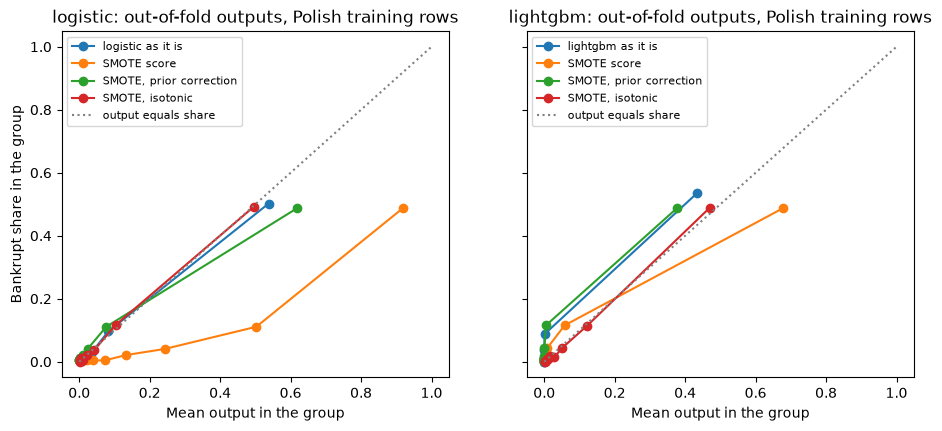

In [28]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

# ten groups of equal size by output; each point is a group's mean output against its bankrupt share
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
for ax, (family, m) in zip(axes, [("logistic", "logistic_smote"), ("lightgbm", "lightgbm_smote")]):
    for label, values in [(f"{family} as it is", outputs[family]), ("SMOTE score", outputs[m]),
                          ("SMOTE, prior correction", corrected[m]), ("SMOTE, isotonic", isotonic[m])]:
        share, mean_output = calibration_curve(y_train, values, n_bins=10, strategy="quantile")
        ax.plot(mean_output, share, marker="o", label=label)
    ax.plot([0, 1], [0, 1], color="grey", linestyle=":", label="output equals share")
    ax.set_title(f"{family}: out-of-fold outputs, Polish training rows")
    ax.set_xlabel("Mean output in the group")
    ax.legend(fontsize=8)
axes[0].set_ylabel("Bankrupt share in the group")
plt.show()

* On the left, the SMOTE score (orange) lies far below the diagonal: its top groups hold far fewer bankrupt companies than their outputs say. The prior correction and isotonic calibration pull it back toward the diagonal, where the logistic regression fitted to the rows as they are already was.
* On the right, LightGBM as it is lies above the diagonal at the top: its highest groups hold more bankrupt companies than its outputs say. Isotonic calibration follows the diagonal; the prior correction does not fix what was there before SMOTE.

**What today shows, on this file.** Resampling and weights moved the outputs a long way and the ranking a little, mostly down. A threshold reached the same recall with fewer flags. If a resampled model is kept, its score is recalibrated before anyone reads it as a probability. Among the logistic regressions, the lowest Brier score belongs to the one that was never resampled or weighted.

## Excel Side by Side

Excel has no worksheet function for SMOTE, for class weights in a fit, or for cross-validation. What it can do is the arithmetic around them: count classes before and after, rebuild one made-up row from its two parents, apply the prior correction, and compute the average output and the Brier score. Every formula below was typed into Excel by script (Excel 16.0 build 20430, 2026-10-05), with the values pasted from Python.

| Job | Python | Excel | Excel returned |
| --- | --- | --- | --- |
| Classes before | `class_counts_after` / `value_counts` | `=COUNTIF(A2:A4681,0)` and `=COUNTIF(A2:A4681,1)` | 4,354 and 326 |
| Classes after SMOTE | `ensemblekit.class_counts_after(...)` | `=COUNTIF(B2:B8709,0)` and `1` on the resampled labels | 4,354 and 4,354 |
| One made-up row | `x + u * (neighbour - x)` | `=B2+$A$6*(B3-B2)` filled across 64 columns, x in row 2, the neighbour in row 3, u in A6 | equal to SMOTE's row |
| The factor k | `(t / (1 - t)) / (f / (1 - f))` | `=(E1/(1-E1))/(E2/(1-E2))` with t in E1, f = 0.5 in E2 | 0.074874 |
| The corrected score | `ensemblekit.prior_correction(score, 0.5, t)` | `=B2*$E$3/(B2*$E$3+1-B2)`, filled down 4,680 rows | equal to Python |
| Average output | `score.mean()` | `=AVERAGE(B2:B4681)` | 0.1947 before, 0.0742 after |
| Brier score | `brier_score_loss(y, score)` | `=SUMXMY2(B2:B4681,A2:A4681)/ROWS(A2:A4681)` | 0.0814 before, 0.0390 after |

**Counting.** With the 4,680 labels in column A and the 8,708 labels after SMOTE in column B, `COUNTIF` on 0 and on 1 gives the class counts on each side: the same numbers `class_counts_after` returned.

**One made-up row.** Paste the bankrupt company's 64 imputed ratios into B2 across, its neighbour's into B3, and `u` into A6. `=B2+$A$6*(B3-B2)` in B4, filled across, is the made-up row: the `$` keeps every column on the same `u`. Excel's row equals the one imbalanced-learn produced.

**The prior correction.** Put the real share in E1 and 0.5 in E2; `=(E1/(1-E1))/(E2/(1-E2))` in E3 is k. With the SMOTE logistic regression's 4,680 out-of-fold scores in column B, `=B2*$E$3/(B2*$E$3+1-B2)` filled down is `prior_correction`, row for row.

**The Brier score.** `SUMXMY2` adds the squared differences of two ranges; divided by `ROWS`, it is the mean squared gap between the score and the outcome, `brier_score_loss`.

Q. Do Excel's numbers equal Python's?

In [29]:
# Excel's numbers, from the course's Excel check, beside Python's for the same rows
logistic_score = outputs["logistic_smote"]
logistic_corrected = corrected["logistic_smote"]
excel = {"made-up row, Attr1": 0.016803267578212336,
         "made-up row, Attr2": 0.40086555295545784,
         "k": 0.07487367937528709,
         "average corrected score": 0.07416750417464105,
         "Brier score before": 0.08135871742027619,
         "Brier score after": 0.03899514315585569}
python = {"made-up row, Attr1": synthetic[0],
          "made-up row, Attr2": synthetic[1],
          "k": (rate / (1 - rate)) / (0.5 / (1 - 0.5)),
          "average corrected score": logistic_corrected.mean(),
          "Brier score before": brier_score_loss(y_train, logistic_score),
          "Brier score after": brier_score_loss(y_train, logistic_corrected)}

side_by_side = pd.DataFrame({"Excel": excel, "Python": python})
side_by_side["within 1e-12"] = (side_by_side["Excel"] - side_by_side["Python"]).abs() < 1e-12
print(side_by_side.to_string())

                            Excel    Python  within 1e-12
made-up row, Attr1       0.016803  0.016803          True
made-up row, Attr2       0.400866  0.400866          True
k                        0.074874  0.074874          True
average corrected score  0.074168  0.074168          True
Brier score before       0.081359  0.081359          True
Brier score after        0.038995  0.038995          True


* Every number matches within 1e-12. Excel computes the made-up row and the corrected scores from the same pasted inputs with the same arithmetic; the differences are in the last digits of a double, so the comparison is printed as "within 1e-12" rather than as the gap itself.

## Save the Day with Git

The work folder gets its own repository, as every day: the code first, then the experiment log.

Q. Make the work folder a repository.

In [30]:
# stop here, with the steps to install it, if Git is not on this machine
if shutil.which("git") is None:
    raise RuntimeError("Git is not installed. Install Git for Windows from https://git-scm.com/downloads "
                       "(or run  winget install --id Git.Git  where your firm allows it), restart VS Code, "
                       "and run this cell again. Colab has Git already.")

# -C "{work}" points every Git command at the work folder, whatever folder the notebook is in
!git -C "{work}" --version
# make the work folder a repository
!git -C "{work}" init -q -b main
# settings for this repository only: a course name, a reserved example email, line endings left as they are,
# and no commit signing, so a signing setup on your machine does not ask for a key here
!git -C "{work}" config user.name "Course Student"
!git -C "{work}" config user.email "student@example.com"
!git -C "{work}" config core.autocrlf false
!git -C "{work}" config commit.gpgsign false

git version 2.50.1.windows.1


Q. Is Git working in the work folder, and only there?

In [31]:
# the guard: Git must report the work folder as the top of this repository, or the notebook stops
top = subprocess.run(["git", "-C", str(work), "rev-parse", "--show-toplevel"],
                     capture_output=True, text=True, check=True).stdout.strip()
assert os.path.samefile(top, work), "Git is not working in the work folder. Stop, and run the setup cell again."
print(f"Git is working in {work.name} and nowhere else")

Git is working in pfi_course5_13_9k8kmy4c and nowhere else


Q. Tell Git which files never to track.

In [32]:
%%writefile .gitignore
__pycache__/
.pytest_cache/
*.xlsx

Writing .gitignore


In [33]:
# ?? marks an untracked file; the data files are copies and stay untracked
!git -C "{work}" status --short

?? .gitignore
?? benchmark.csv
?? credit_card_default.csv
?? ensemblekit.py
?? mlkit.py
?? polish_bankruptcy_5year.csv
?? ratings.csv
?? test_ensemblekit.py


Q. Commit `.gitignore`, Course 4's module, and the two files as they stand after today's functions.

In [34]:
!git -C "{work}" add .gitignore mlkit.py ensemblekit.py test_ensemblekit.py
!git -C "{work}" commit -q -m "Resampling inside the pipeline: class_counts_after and prior_correction, 50 tests"
!git -C "{work}" log --oneline

f91c657 Resampling inside the pipeline: class_counts_after and prior_correction, 50 tests


Q. Write today's eight models to `results.csv`, scored by cross-validation, with 4 decimals.

In [35]:
# one row per model: the rows scored ("cv": out-of-fold on the training rows), its ranking metrics, and its flags at
# the out-of-fold threshold for recall 0.70
rows = []
for m in order:
    metrics = mlkit.classification_metrics(y_train, (outputs[m] >= thresholds[m]).astype(int))
    rows.append({"model": m, "rows": "cv", "roc_auc": roc_auc_score(y_train, outputs[m]),
                 "average_precision": average_precision_score(y_train, outputs[m]), "threshold": thresholds[m], **metrics})
results = pd.DataFrame(rows)
# 4 decimals and LF line endings, so a later diff shows a real change and prints the same everywhere
results.to_csv("results.csv", index=False, float_format="%.4f", lineterminator="\n")
print((work / "results.csv").read_text(encoding="utf-8"))
print(f"accuracy of flagging no company (all-zero baseline): {1 - rate:.4f}")

model,rows,roc_auc,average_precision,threshold,accuracy,precision,recall,f1
lightgbm,cv,0.9496,0.7543,0.0255,0.9556,0.6735,0.7025,0.6877
lightgbm_balanced,cv,0.9437,0.7483,0.0745,0.9558,0.6755,0.7025,0.6887
lightgbm_oversampled,cv,0.9492,0.7595,0.1088,0.9607,0.7247,0.7025,0.7134
lightgbm_undersampled,cv,0.9240,0.5035,0.9809,0.9216,0.4589,0.7025,0.5552
lightgbm_smote,cv,0.9272,0.6471,0.1677,0.9276,0.4862,0.7025,0.5747
logistic,cv,0.9202,0.6841,0.1735,0.9387,0.5465,0.7025,0.6148
logistic_balanced,cv,0.9264,0.6497,0.7134,0.9254,0.4761,0.7025,0.5675
logistic_smote,cv,0.9212,0.6597,0.7251,0.9278,0.4872,0.7025,0.5754

accuracy of flagging no company (all-zero baseline): 0.9303


* The log's nine columns, as every classification day. Every threshold comes from out-of-fold outputs on the training rows, and every recall is 0.7025, so precision and the flag counts carry the comparison. Accuracy sits beside the all-zero baseline, 0.9303, and chooses nothing.

In [36]:
!git -C "{work}" add results.csv
!git -C "{work}" commit -q -m "Experiment log: eight ways to treat a rare outcome, scored by out-of-fold rows of the Polish training set"

Q. Today's Git step: show the history with its labels.

In [37]:
# --decorate prints the labels that point at a commit: HEAD (where you are) and the branch main
!git -C "{work}" log --oneline --decorate

f0af129 (HEAD -> main) Experiment log: eight ways to treat a rare outcome, scored by out-of-fold rows of the Polish training set
f91c657 Resampling inside the pipeline: class_counts_after and prior_correction, 50 tests


* `(HEAD -> main)` sits on the last commit: `HEAD` is the commit you are on, `main` is the branch, and the arrow says `HEAD` follows `main`, so the next commit moves both. Tags, from tomorrow, appear in the same brackets.

## Bring It Home

Add today's two functions to your own `my_bondmath` folder. Open a PowerShell terminal in VS Code.

**Step 1.** Go to your folder. The Polish file is there from day 11, and `ensemblekit.py` as day 12 left it.

```powershell
Set-Location "$HOME\projects\my_bondmath"
Test-Path polish_bankruptcy_5year.csv
code ensemblekit.py
code test_ensemblekit.py
```

**Step 2.** Paste the code of the two `%%writefile -a ensemblekit.py` cells (sections 13.2 and 13.8), without their first lines, at the end of `ensemblekit.py`; do the same for the two `test_ensemblekit.py` cells. Save both.

**Step 3.** Run the tests.

```powershell
python -m pytest -q test_ensemblekit.py
```

The last line says `50 passed`.

**Step 4.** Look at the change, then commit the code only.

```powershell
git diff --stat
git add ensemblekit.py test_ensemblekit.py
git commit -m "Resampling inside the pipeline: class_counts_after and prior_correction, 50 tests"
git log --oneline --decorate -3
```

**At work.** Before resampling anything, fit the model to the rows as they are, set the threshold for the recall you need on out-of-fold outputs, and see what it costs. If a pipeline from a colleague or an AI answer resamples, check that the sampler is a step of an `imblearn` pipeline, not a line before the cross-validation.

**In Colab**, download `ensemblekit.py` and `test_ensemblekit.py` from the work folder under `/tmp` in the file browser.

## You Can Now

* Name the four ways to make a rare class count, and count what each resampler does to the rows with `class_counts_after`.
* Find the two parents and the step `u` of a row SMOTE made up, and rebuild it in Excel.
* Put a sampler inside an `ImbPipeline`, and say why SMOTE before cross-validation reports a score near 1.
* Rank models by pooled out-of-fold average precision, and say why weights and resampling move the output more than the ranking.
* Reach a recall with a threshold on the unweighted model, and compare models by the flags it costs.
* Call a weighted or resampled output the model's score, and recalibrate it with `prior_correction` or isotonic calibration.

Tomorrow, day 14: SHAP values, how one company's score splits across its 64 ratios, and what that split does not say.

## Exercises

The exercises use Course 4's Polish training rows, scored by cross-validation inside them; the test rows are closed. Every answer describes this file. Replace each `...` with your own code, then run the check cell. Worked answers are in the solutions notebook in this folder.

Q. Run the next cell first. It loads the rows, defines today's helpers, scores the logistic regression fitted to the rows as they are, and defines `check`, a small function that marks your answers.

In [38]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score
from sklearn.model_selection import cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import QuantileTransformer
from sklearn.tree import DecisionTreeClassifier

# Course 4's Polish training rows
polish = pd.read_csv("polish_bankruptcy_5year.csv", float_precision="round_trip")
X_train, y_train = ensemblekit.course4_polish_rows(polish)


def booster(**settings):
    """LightGBM with the day's settings: 200 trees, the course seed, one thread, no console output."""
    return LGBMClassifier(n_estimators=200, random_state=SEED, n_jobs=1, verbose=-1, **settings)


def fill():
    """The median imputer, fitted inside a pipeline."""
    return SimpleImputer(strategy="median")


# section 13.5's logistic regression fitted to the rows as they are, and its out-of-fold probabilities
plain_logistic = Pipeline([("impute", SimpleImputer(strategy="median", add_indicator=True)),
                           ("quantile", QuantileTransformer(output_distribution="normal", random_state=SEED)),
                           ("model", LogisticRegression(solver="newton-cholesky", tol=1e-8))])
_, proba_logistic = ensemblekit.oof_threshold(plain_logistic, X_train, y_train)


def check(label, answer, expected):
    """Compare an exercise answer with the expected value and print the result."""
    if answer is ...:
        print(f"{label}: not attempted yet")
        return
    if isinstance(expected, float):
        # numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 1e-6
    else:
        correct = answer == expected
    if correct:
        print(f"{label}: correct")
    else:
        print(f"{label}: not yet. You have {answer}.")

### Exercise 1

Q. SMOTE looks at each bankrupt company's five nearest bankrupt neighbours by default. Fit section 13.4's LightGBM pipeline with `SMOTE(k_neighbors=3, random_state=SEED)` instead, score it with `ensemblekit.oof_threshold`, and store its pooled out-of-fold average precision in **ex1_ap**.

In [39]:
ex1_ap = ...

In [40]:
check("Exercise 1 SMOTE with three neighbours", ex1_ap, 0.6462881638088973)

Exercise 1 SMOTE with three neighbours: not attempted yet


### Exercise 2

Q. Undersampling with a forest: put `RandomUnderSampler(random_state=SEED)` between the median imputer and `RandomForestClassifier(n_estimators=100, min_samples_leaf=3, random_state=SEED, n_jobs=1)` in an `ImbPipeline`. Score it with `oof_threshold` and store its pooled out-of-fold average precision in **ex2_ap** and its average output in **ex2_mean**.

In [41]:
ex2_ap = ...
ex2_mean = ...

In [42]:
check("Exercise 2 the undersampled forest's average precision", ex2_ap, 0.3788365044638383)
check("Exercise 2 its average output", ex2_mean, 0.3366342664458049)

Exercise 2 the undersampled forest's average precision: not attempted yet
Exercise 2 its average output: not attempted yet


### Exercise 3

Q. Add a function to your module. `flag_count_at_recall(y, proba, target=0.70)` returns how many rows are flagged at `mlkit.threshold_for_recall(y, proba, target)`. Write the docstring first. Then add `test_flag_count_at_recall_hand`: with outcomes 0, 0, 1, 1 and outputs 0.1, 0.6, 0.4, 0.8, recall 0.5 flags one row and recall 1.0 flags three, and outcomes with no 1 raise `ValueError`. Run pytest, reload the module, and store `ensemblekit.flag_count_at_recall(y_train, proba_logistic, 0.70)` in **ex3_flagged**.

Write the function in the cell that starts with `%%writefile -a ensemblekit.py` and the test in the one that starts with `%%writefile -a test_ensemblekit.py`, and run each of those cells once.

In [43]:
%%writefile -a ensemblekit.py


# Exercise 3: write flag_count_at_recall(y, proba, target) below this line

Appending to ensemblekit.py


In [44]:
%%writefile -a test_ensemblekit.py


# Exercise 3: write test_flag_count_at_recall_hand() below this line

Appending to test_ensemblekit.py


In [45]:
# run pytest, reload the module, then call your function
ex3_flagged = ...

In [46]:
check("Exercise 3 flags at recall 0.70", ex3_flagged, 419)

Exercise 3 flags at recall 0.70: not attempted yet


### Exercise 4: AI check

You ask an AI assistant for a function that scores a model with SMOTE by cross-validation, and you give it a docstring as the request. **The docstring is the prompt.** This is what you gave it:

```
Out-of-fold class-1 probabilities of model, with SMOTE balancing the classes.

    The median imputer and SMOTE are fitted on each fold's training rows only, so every held-out row is an
    original row, scored as it is. Returns one probability per row of X, in X's order.
```

The function below came back. It was written for this course in the style of an AI assistant's answer. It runs without an error, returns probabilities between 0 and 1, and contains one bug. The model to try it on is a depth-4 tree, quick to fit:

In [47]:
# a small, quick model for the check
ai_model = DecisionTreeClassifier(max_depth=4, random_state=SEED)

In [48]:
# written for this course in the style of an AI assistant's answer. It runs, and it contains one bug.
def smote_oof_proba(model, X, y):
    """Out-of-fold class-1 probabilities of model, with SMOTE balancing the classes.

    The median imputer and SMOTE are fitted on each fold's training rows only, so every held-out row is an
    original row, scored as it is. Returns one probability per row of X, in X's order.
    """
    filled = SimpleImputer(strategy="median").fit_transform(X)
    # balance the classes first, so every fold sees as many bankrupt rows as healthy ones
    X_balanced, y_balanced = SMOTE(random_state=SEED).fit_resample(filled, y)
    return cross_val_predict(model, X_balanced, y_balanced, cv=mlkit.cv_folds(), method="predict_proba", n_jobs=1)[:, 1]

Q. Before you run the next cell: how many probabilities should `smote_oof_proba(ai_model, X_train, y_train)` return for 4,680 training rows, by its docstring? How many will it return?

In [49]:
ai_proba = smote_oof_proba(ai_model, X_train, y_train)
print(f"{len(ai_proba):,} probabilities for {len(X_train):,} training rows, from {ai_proba.min():.4f} to {ai_proba.max():.4f}")

8,708 probabilities for 4,680 training rows, from 0.0000 to 1.0000


Q. Test the function against its docstring before you trust it.

In [50]:
# the test, written from the docstring before the code is trusted
ai_proba = smote_oof_proba(ai_model, X_train, y_train)

# 1. one probability per training row: every scored row is an original row
assert len(ai_proba) == len(X_train), f"{len(ai_proba):,} probabilities for {len(X_train):,} rows: made-up rows were scored"
# 2. the same probabilities as SMOTE inside an imblearn pipeline, which resamples each fold's training rows only
inside = ImbPipeline([("impute", SimpleImputer(strategy="median")), ("smote", SMOTE(random_state=SEED)),
                      ("model", ai_model)])
expected = ensemblekit.oof_threshold(inside, X_train, y_train)[1]
assert np.allclose(ai_proba, expected, rtol=0, atol=1e-12), "not the probabilities of SMOTE inside the pipeline"
print(f"{len(ai_proba):,} probabilities, pooled out-of-fold average precision {average_precision_score(y_train, ai_proba):.4f}")

AssertionError: 8,708 probabilities for 4,680 rows: made-up rows were scored

Q. Read the test's message, fix the function in the cell that defines it, and run that cell and the test again until the test passes. Then store `len(smote_oof_proba(ai_model, X_train, y_train))` in **ex4_rows**.

In [51]:
# fix the function above and run the test again, then store the answer
ex4_rows = ...

In [52]:
check("Exercise 4 probabilities from the fixed function", ex4_rows, 4680)

Exercise 4 probabilities from the fixed function: not attempted yet


## Tidying Up

The work folder stays where it is, so you can open it: its name was printed by the setup cell, and on Windows it is under `$env:TEMP`. Every run of the setup cell makes a new one. To delete a work folder, run these lines in a cell of the same notebook session. Git marks its own files read-only, and on Windows a plain delete stops at them with a `PermissionError`, so the handler clears that flag and tries again.

```python
import stat

def clear_read_only(function, path, error):
    """Make a read-only file writable, then retry the delete that failed on it."""
    os.chmod(path, stat.S_IWRITE)
    function(path)

os.chdir(notebook_folder)
shutil.rmtree(work, onexc=clear_read_only)
print(f"{work.name} exists: {work.exists()}")
```